# Exploratory Data Analysis — Feature Selection Justification

This notebook provides **visual and statistical evidence** for every feature selected in the final CatBoost diabetes classifier.  
The workflow proceeds in 8 sections:

| # | Section | Purpose |
|---|---------|--------|
| 1 | Setup & data loading | Load raw NHANES XPT files, create binary target |
| 2 | Class imbalance | Show diabetes prevalence |
| 3 | Univariate EDA per feature group | Distribution + diabetes rate plots |
| 4 | Correlation heatmap | Feature–target correlations |
| 5 | Statistical tests | Chi-square / Mann–Whitney for every candidate |
| 6 | Mutual Information | Non-linear relevance ranking |
| 7 | Baseline model feature importance | CatBoost feature importance |
| 8 | Feature pruning summary | Why we kept / dropped each candidate |

## 1. Setup & Data Loading

In [221]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif
from catboost import CatBoostClassifier, Pool

# ─── Aesthetic Color Palette ───
COLORS = {
    'no_diab': '#457B9D',   # steel blue
    'diab':    '#E63946',   # crimson
    'accent':  '#6A4C93',   # royal purple
    'neutral': '#8D99AE',   # cool grey
    'bg':      '#F8F9FA',   # clean white
    'grid':    '#E2E8F0',   # blue-grey grid
    'success': '#2A9D8F',   # dark teal
    'warn':    '#E9C46A',   # honey gold
    'dark':    '#1D3557',   # midnight navy
    'light':   '#A8DADC',   # ice blue (heatmap low end)
}

PAL = [COLORS['no_diab'], COLORS['diab']]
PAL_NAMED = {'No Diabetes': COLORS['no_diab'], 'Diabetes': COLORS['diab']}

plt.rcParams.update({
    'figure.facecolor':    COLORS['bg'],
    'axes.facecolor':      '#FFFFFF',
    'axes.edgecolor':      COLORS['grid'],
    'axes.grid':           True,
    'grid.color':          COLORS['grid'],
    'grid.alpha':          0.5,
    'grid.linewidth':      0.5,
    'grid.linestyle':      '--',
    'figure.dpi':          140,
    'savefig.dpi':         180,
    'savefig.bbox':        'tight',
    'font.family':         'sans-serif',
    'font.sans-serif':     ['Segoe UI', 'Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'font.size':           11,
    'axes.titlesize':      14,
    'axes.titleweight':    'bold',
    'axes.titlepad':       14,
    'axes.labelsize':      11,
    'axes.labelpad':       8,
    'xtick.labelsize':     10,
    'ytick.labelsize':     10,
    'xtick.major.pad':     5,
    'ytick.major.pad':     5,
    'legend.fontsize':     10,
    'legend.framealpha':   0.92,
    'legend.edgecolor':    COLORS['grid'],
    'lines.linewidth':     2,
    'patch.edgecolor':     'white',
})

sns.set_theme(style='whitegrid', font_scale=1.05,
              rc={'axes.facecolor': '#FFFFFF', 'figure.facecolor': COLORS['bg']})
sns.set_palette(PAL)

RAW = 'data/raw/'

# ─── Variable Lookup ───
variables_df = pd.read_csv('data/extra/variables.csv')

def desc(variable_name):
    """Look up variable information from variables_df."""
    is_missing = variable_name.endswith('_missing')
    base_var = variable_name.replace('_missing', '') if is_missing else variable_name
    row = variables_df[variables_df['Variable Name'] == base_var]
    if row.empty:
        return {
            'renamed': variable_name,
            'description': 'Variable not in variables.csv',
            'data_file': None,
            'file_description': 'Derived_variable'
        }
    row = row.iloc[0]
    renamed = row['Renamed_variables']
    if is_missing:
        renamed = f"{renamed}_missing"
    return {
        'renamed': renamed,
        'description': row['Variable Description'],
        'data_file': row['Data File Name'],
        'file_description': row['Data File Description']
    }

def nice(var, wrap=0):
    """Return a short, human-readable label for a variable code.
    If wrap > 0, insert newlines so no line exceeds `wrap` characters."""
    info = desc(var)
    label = info['renamed']
    # Replace underscores with spaces
    label = label.replace('_', ' ')
    # Insert spaces before uppercase runs in camelCase
    label = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', label)
    # Collapse multiple spaces
    label = re.sub(r' +', ' ', label).strip()
    # Truncate for plot readability
    if len(label) > 40:
        label = label[:37] + '…'
    # Auto-wrap long labels
    if wrap > 0 and len(label) > wrap:
        words = label.split()
        lines, current = [], ''
        for w in words:
            if current and len(current) + 1 + len(w) > wrap:
                lines.append(current)
                current = w
            else:
                current = f'{current} {w}'.strip() if current else w
        if current:
            lines.append(current)
        label = '\n'.join(lines)
    return label

def nice_list(vars_list, wrap=0):
    """Map a list of variable codes to nice labels."""
    return [nice(v, wrap=wrap) for v in vars_list]

# ─── Data Helpers ───
def load_xpt(name, cols=None):
    df = pd.read_sas(os.path.join(RAW, f'{name}.XPT'), format='xport', encoding='utf-8')
    df.columns = [c.strip() for c in df.columns]
    if cols:
        cols = ['SEQN'] + [c for c in cols if c in df.columns and c != 'SEQN']
        df = df[cols]
    for c in df.columns:
        if df[c].dtype == object:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

def remove_sentinels(df):
    """Replace 999/777-type sentinel values with NaN."""
    for col in df.columns:
        if col == 'SEQN' or not pd.api.types.is_numeric_dtype(df[col]):
            continue
        mx = df[col].max()
        if pd.isna(mx) or mx <= 0:
            continue
        mx_str = str(int(mx)).lstrip('-').rstrip('0').rstrip('.')
        if mx_str and mx_str.isdigit() and all(c == '9' for c in mx_str):
            second = 7 * mx / 9
            df.loc[df[col].isin([mx, second]), col] = np.nan
    return df

def add_gradient_bar(ax, x, heights, cmap_name='coolwarm', edgecolor='white', lw=0.8, **kwargs):
    """Draw bars with individual gradient-mapped colours."""
    cmap = plt.cm.get_cmap(cmap_name)
    norm = plt.Normalize(min(heights), max(heights))
    bars = ax.bar(x, heights, color=[cmap(norm(h)) for h in heights],
                  edgecolor=edgecolor, linewidth=lw, **kwargs)
    return bars, cmap, norm

def annotate_bars(ax, bars, counts=None, fmt='{:.1%}', offset=0.01, fontsize=9, color=None):
    """Annotate bars with values and optional sample counts."""
    if color is None:
        color = COLORS['dark']
    for i, bar in enumerate(bars):
        h = bar.get_height()
        label = fmt.format(h)
        if counts is not None:
            label += f'\nn={counts[i]:,}'
        ax.text(bar.get_x() + bar.get_width()/2, h + offset, label,
                ha='center', va='bottom', fontsize=fontsize, color=color, fontweight='medium')

# Quick test
print('✓ Aesthetic theme loaded. Helper functions ready.')
print(f'  nice("BPQ080") → "{nice("BPQ080")}"')
print(f'  nice("HUQ010") → "{nice("HUQ010")}"')
print(f'  nice("Hypertension_Ever") → "{nice("Hypertension_Ever")}"')

✓ Aesthetic theme loaded. Helper functions ready.
  nice("BPQ080") → "Ever Told High Cholesterol"
  nice("HUQ010") → "General Health Status"
  nice("Hypertension_Ever") → "Hypertension Ever"


In [222]:
# ── Load diabetes target ──
diab = load_xpt('diabetes', ['SEQN', 'DIQ010', 'DIQ160'])
pre = (diab['DIQ010'] == 3) | ((diab['DIQ010'] == 2) & (diab['DIQ160'] == 1))
diab = diab[~pre].copy()
diab['diabetes_class'] = (diab['DIQ010'] == 1).astype(int)
target = diab[['SEQN', 'diabetes_class']].dropna()
base_seqn = target['SEQN']

print(f'Target loaded: {len(target)} respondents')
print(target['diabetes_class'].value_counts())

Target loaded: 10542 respondents
diabetes_class
0    9461
1    1081
Name: count, dtype: int64


## 2. Class Imbalance

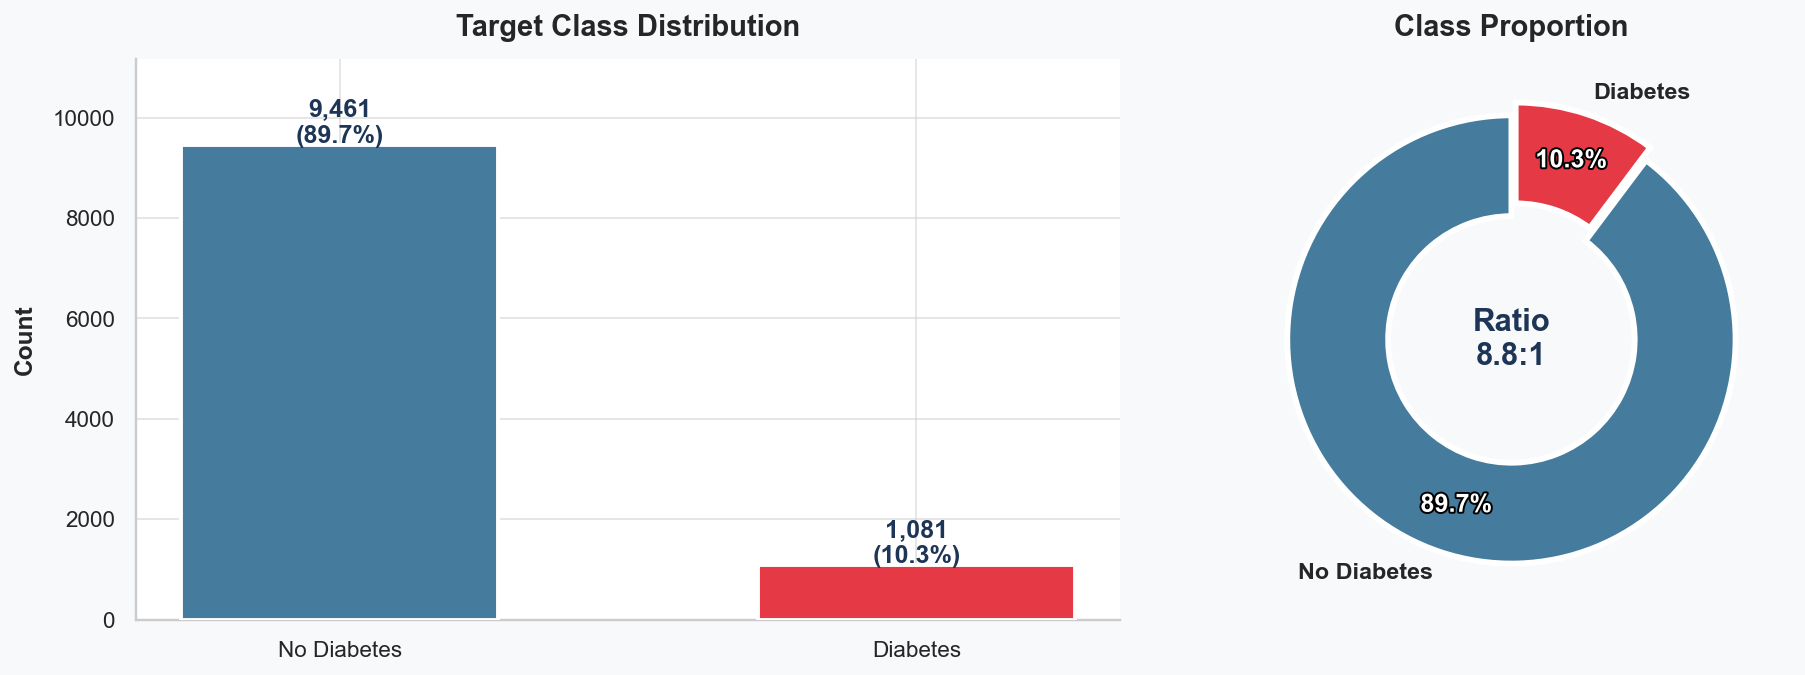


Imbalance ratio: 8.8 : 1  (No Diabetes : Diabetes)


In [223]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.2, 1]})

vc = target['diabetes_class'].value_counts().sort_index()

# ── LEFT: Annotated bar with gradient ──
ax = axes[0]
bars = ax.bar(['No Diabetes', 'Diabetes'], vc.values,
              color=[COLORS['no_diab'], COLORS['diab']],
              edgecolor='white', linewidth=2, width=0.55, zorder=3)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 40,
            f'{v:,}\n({v/vc.sum():.1%})', ha='center', fontweight='bold',
            fontsize=13, color=COLORS['dark'])
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Target Class Distribution', fontsize=15, pad=12)
ax.set_ylim(0, vc.max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)

# ── RIGHT: Donut chart ──
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    vc.values, labels=['No Diabetes', 'Diabetes'],
    autopct='%1.1f%%', pctdistance=0.78,
    colors=[COLORS['no_diab'], COLORS['diab']],
    startangle=90, explode=(0, 0.06),
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=3),
    textprops=dict(fontsize=12, fontweight='bold'),
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')
    at.set_path_effects([pe.withStroke(linewidth=2, foreground='black')])
# Centre annotation
ax2.text(0, 0, f'Ratio\n{vc[0]/vc[1]:.1f}:1', ha='center', va='center',
         fontsize=16, fontweight='bold', color=COLORS['dark'])
ax2.set_title('Class Proportion', fontsize=15, pad=12)

plt.tight_layout()
os.makedirs('Results/exploring', exist_ok=True)
plt.savefig('Results/exploring/class_imbalance.png', bbox_inches='tight')
plt.show()
print(f'\nImbalance ratio: {vc[0]/vc[1]:.1f} : 1  (No Diabetes : Diabetes)')


## 3. Univariate EDA — Per Feature Group

For each feature group, we show:
- **Distributions** split by diabetes status
- **Diabetes prevalence rates** across categories / bins

This builds the intuition for *why* each feature is predictive.

### 3.1 Blood Pressure & Cholesterol
Features: `BPQ080` (high cholesterol), `BPQ101D` (cholesterol medication), `Hypertension_Ever`, `Hypertension_OnMedication`

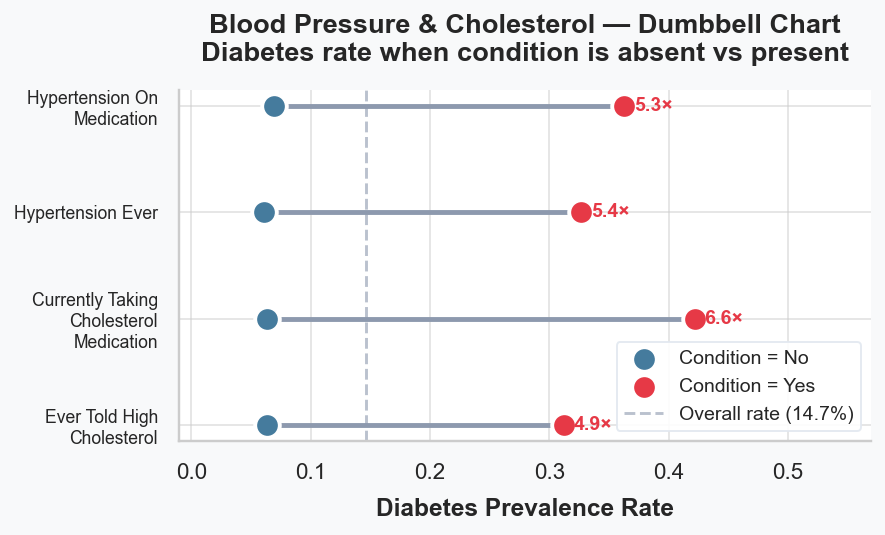

In [224]:
bp = load_xpt('blood_pressure_cholesterol')
bp = remove_sentinels(bp)
bp = bp.merge(target, on='SEQN', how='inner')

bp['Hypertension_Ever'] = (bp['BPQ020'] == 1).astype(int)
bp['Hypertension_OnMedication'] = ((bp['BPQ020'] == 1) & (bp['BPQ150'] == 1)).astype(int)

bp_features = ['BPQ080', 'BPQ101D', 'Hypertension_Ever', 'Hypertension_OnMedication']

# ── Dumbbell chart: diabetes rate when condition = No vs Yes ──
fig, ax = plt.subplots(figsize=(6.5,4))

rate_no, rate_yes, lifts, labels = [], [], [], []

for col in bp_features:
    if col not in bp.columns:
        continue
    tmp = bp[[col, 'diabetes_class']].dropna()
    r0 = tmp[tmp[col] != 1]['diabetes_class'].mean()
    r1 = tmp[tmp[col] == 1]['diabetes_class'].mean()
    rate_no.append(r0)
    rate_yes.append(r1)
    lifts.append(r1 / (r0 + 1e-9))
    labels.append(nice(col, wrap=18))

y_pos = np.arange(len(labels))

for i in range(len(labels)):
    ax.plot([rate_no[i], rate_yes[i]], [i, i], color=COLORS['neutral'],
            linewidth=2.5, zorder=1)

ax.scatter(rate_no, y_pos, s=160, color=COLORS['no_diab'], edgecolors='white',
           linewidths=2, zorder=3, label='Condition = No')
ax.scatter(rate_yes, y_pos, s=160, color=COLORS['diab'], edgecolors='white',
           linewidths=2, zorder=3, label='Condition = Yes')

for i in range(len(labels)):
    ax.annotate(f'{lifts[i]:.1f}×',
                xy=(rate_yes[i] + 0.008, i), fontsize=10,
                fontweight='bold', color=COLORS['diab'], va='center')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Diabetes Prevalence Rate', fontweight='bold')
ax.set_title('Blood Pressure & Cholesterol — Dumbbell Chart\nDiabetes rate when condition is absent vs present',
             fontsize=14, pad=15)
ax.axvline(bp['diabetes_class'].mean(), ls='--', color=COLORS['neutral'],
           alpha=0.6, label=f'Overall rate ({bp["diabetes_class"].mean():.1%})')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(-0.01, max(rate_yes) * 1.35)

plt.tight_layout()
plt.savefig('Results/exploring/eda_blood_pressure.png', bbox_inches='tight')
plt.show()


### 3.2 Weight & Body Composition
Features: `WHD010` (height), `WHD020` (current weight), `WHD050` (weight 1 yr ago), `WHQ070` (tried to lose weight), plus engineered `BMI` and `WeightChange`

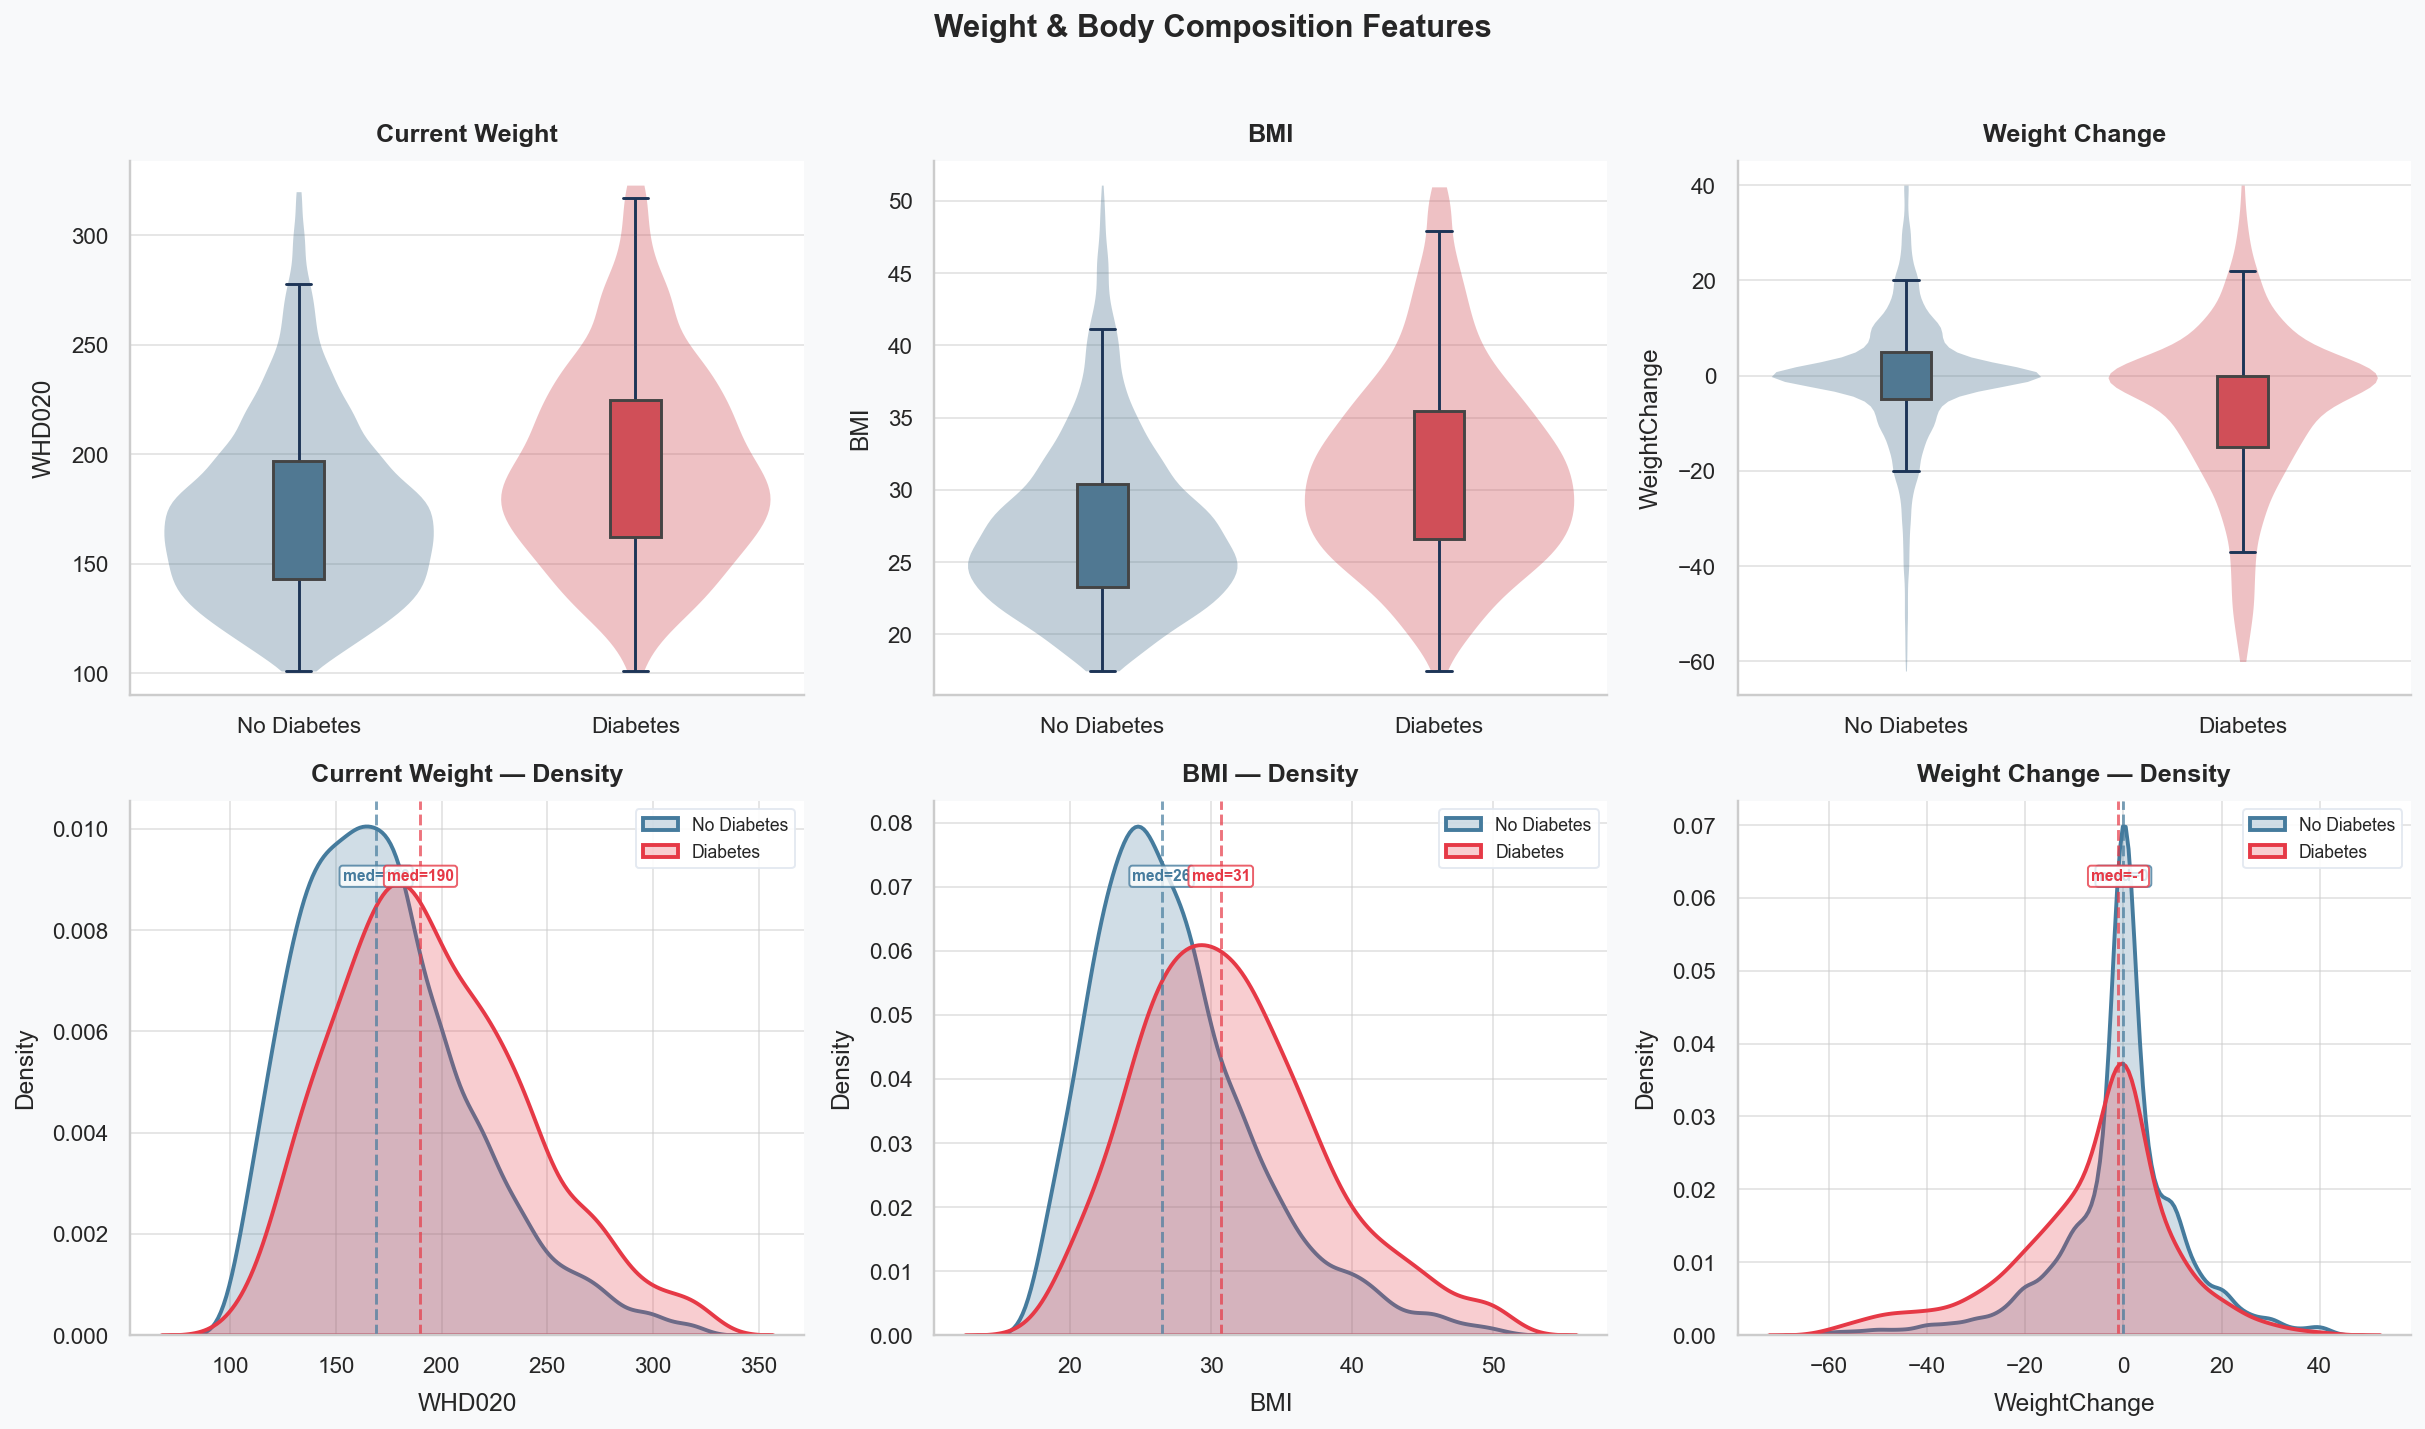

In [225]:
wt = load_xpt('weight_history')
wt = remove_sentinels(wt)
wt = wt.merge(target, on='SEQN', how='inner')

wt['BMI'] = (wt['WHD020'] * 703) / (wt['WHD010'] ** 2)
wt['WeightChange'] = wt['WHD020'] - wt['WHD050']

continuous_wt = ['WHD020', 'BMI', 'WeightChange']

fig, axes = plt.subplots(2, 3, figsize=(17.5, 10))

for i, col in enumerate(continuous_wt):
    label = nice(col)
    tmp = wt[[col, 'diabetes_class']].dropna()
    tmp = tmp[(tmp[col] > tmp[col].quantile(0.01)) & (tmp[col] < tmp[col].quantile(0.99))]

    # Row 1: Violin + box overlay
    ax = axes[0, i]
    plot_df = tmp.copy()
    plot_df['Class'] = plot_df['diabetes_class'].map({0: 'No Diabetes', 1: 'Diabetes'})
    sns.violinplot(data=plot_df, x='Class', y=col, ax=ax,
                   palette=PAL_NAMED, inner=None, cut=0, linewidth=0, alpha=0.35)
    sns.boxplot(data=plot_df, x='Class', y=col, ax=ax,
                palette=PAL_NAMED, width=0.15, linewidth=1.5,
                boxprops=dict(zorder=3), medianprops=dict(color='white', lw=2),
                whiskerprops=dict(color=COLORS['dark']),
                capprops=dict(color=COLORS['dark']),
                fliersize=0)
    ax.set_title(label, fontsize=13, pad=10)
    ax.set_xlabel('')
    ax.spines[['top', 'right']].set_visible(False)

    # Row 2: KDE with fill + median lines
    ax2 = axes[1, i]
    for cls, color, lbl in [(0, COLORS['no_diab'], 'No Diabetes'),
                             (1, COLORS['diab'], 'Diabetes')]:
        subset = tmp[tmp['diabetes_class'] == cls][col]
        sns.kdeplot(subset, ax=ax2, color=color, label=lbl, fill=True, alpha=0.25, linewidth=2)
        med = subset.median()
        ax2.axvline(med, color=color, ls='--', lw=1.5, alpha=0.7)
        ax2.text(med, ax2.get_ylim()[1] * 0.85, f'med={med:.0f}',
                 color=color, fontsize=8, fontweight='bold', ha='center',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.8))
    ax2.set_title(f'{label} — Density', fontsize=13, pad=10)
    ax2.legend(fontsize=9)
    ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Weight & Body Composition Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Results/exploring/eda_weight_body.png', bbox_inches='tight')
plt.show()


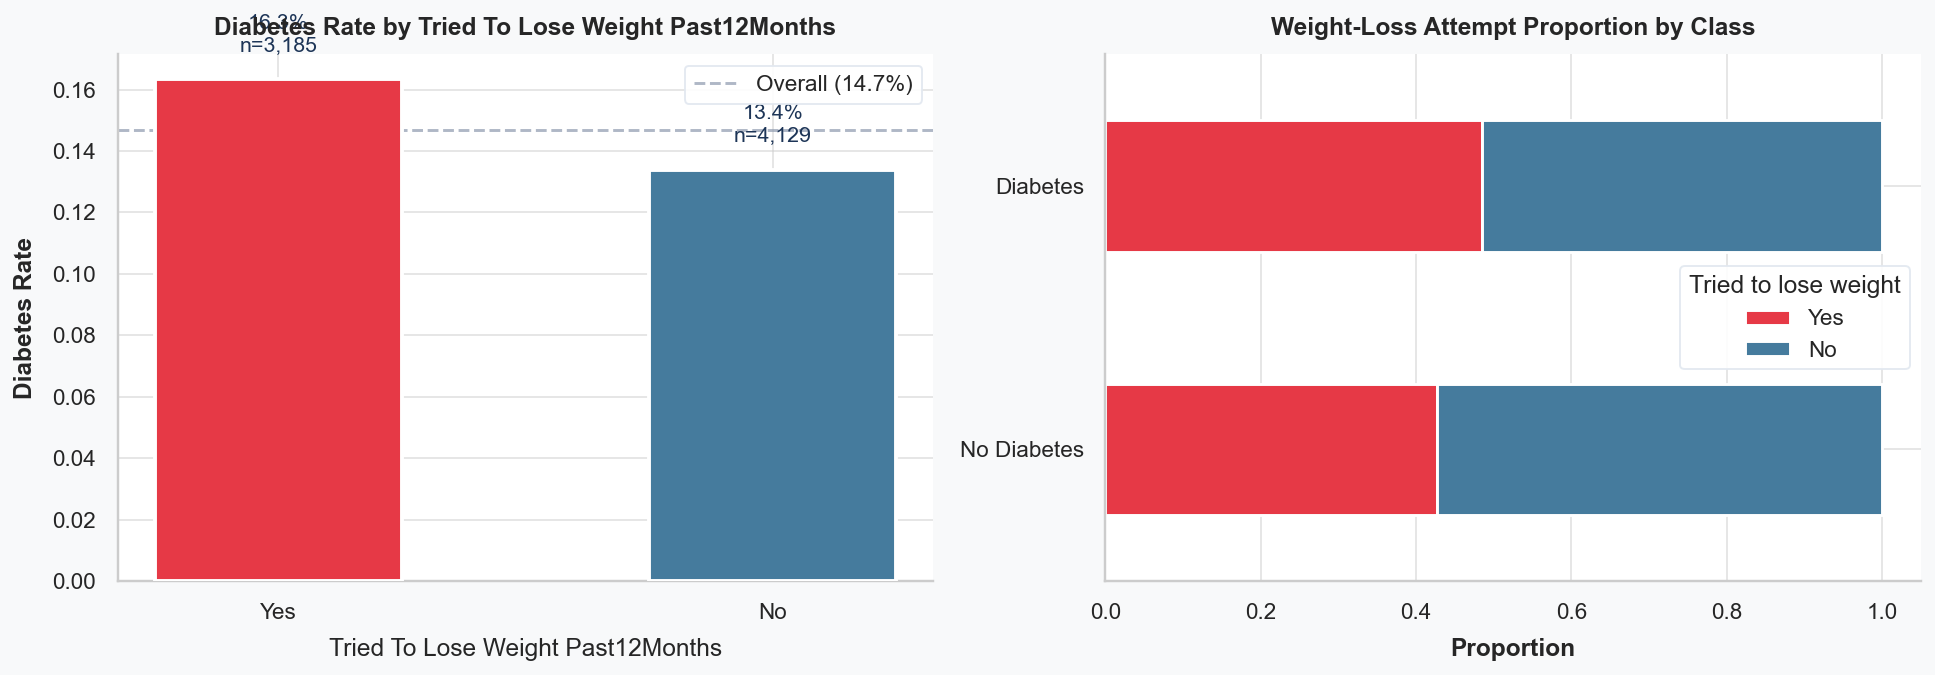

In [226]:
# WHQ070 - Tried to lose weight (categorical) — enhanced
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tmp = wt[['WHQ070', 'diabetes_class']].dropna()
rate = tmp.groupby('WHQ070')['diabetes_class'].agg(['mean', 'count']).reset_index()
labels_whq = {1.0: 'Yes', 2.0: 'No'}
rate['label'] = rate['WHQ070'].map(labels_whq).fillna(rate['WHQ070'].astype(str))

# Left: Diabetes rate comparison
bars = axes[0].bar(rate['label'], rate['mean'],
                   color=[COLORS['diab'], COLORS['no_diab']], edgecolor='white',
                   linewidth=2, width=0.5, zorder=3)
annotate_bars(axes[0], bars, counts=rate['count'].values, offset=0.008, fontsize=11)
axes[0].axhline(tmp['diabetes_class'].mean(), ls='--', color=COLORS['neutral'],
                alpha=0.7, label=f'Overall ({tmp["diabetes_class"].mean():.1%})')
axes[0].set_ylabel('Diabetes Rate', fontweight='bold')
axes[0].set_xlabel(nice('WHQ070'))
axes[0].set_title(f'Diabetes Rate by {nice("WHQ070")}', pad=10)
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Right: Proportion of weight-loss attempt by diabetes class
ct = pd.crosstab(tmp['diabetes_class'], tmp['WHQ070'], normalize='index')
ct.index = ['No Diabetes', 'Diabetes']
ct.columns = [labels_whq.get(c, str(c)) for c in ct.columns]
ct.plot(kind='barh', stacked=True, ax=axes[1],
        color=[COLORS['diab'], COLORS['no_diab']], edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Proportion', fontweight='bold')
axes[1].set_title('Weight-Loss Attempt Proportion by Class', pad=10)
axes[1].legend(title='Tried to lose weight', framealpha=0.9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 3.3 General Health & Hospital Utilisation
Feature: `HUQ010` (self-reported general health condition, 1=Excellent → 5=Poor)

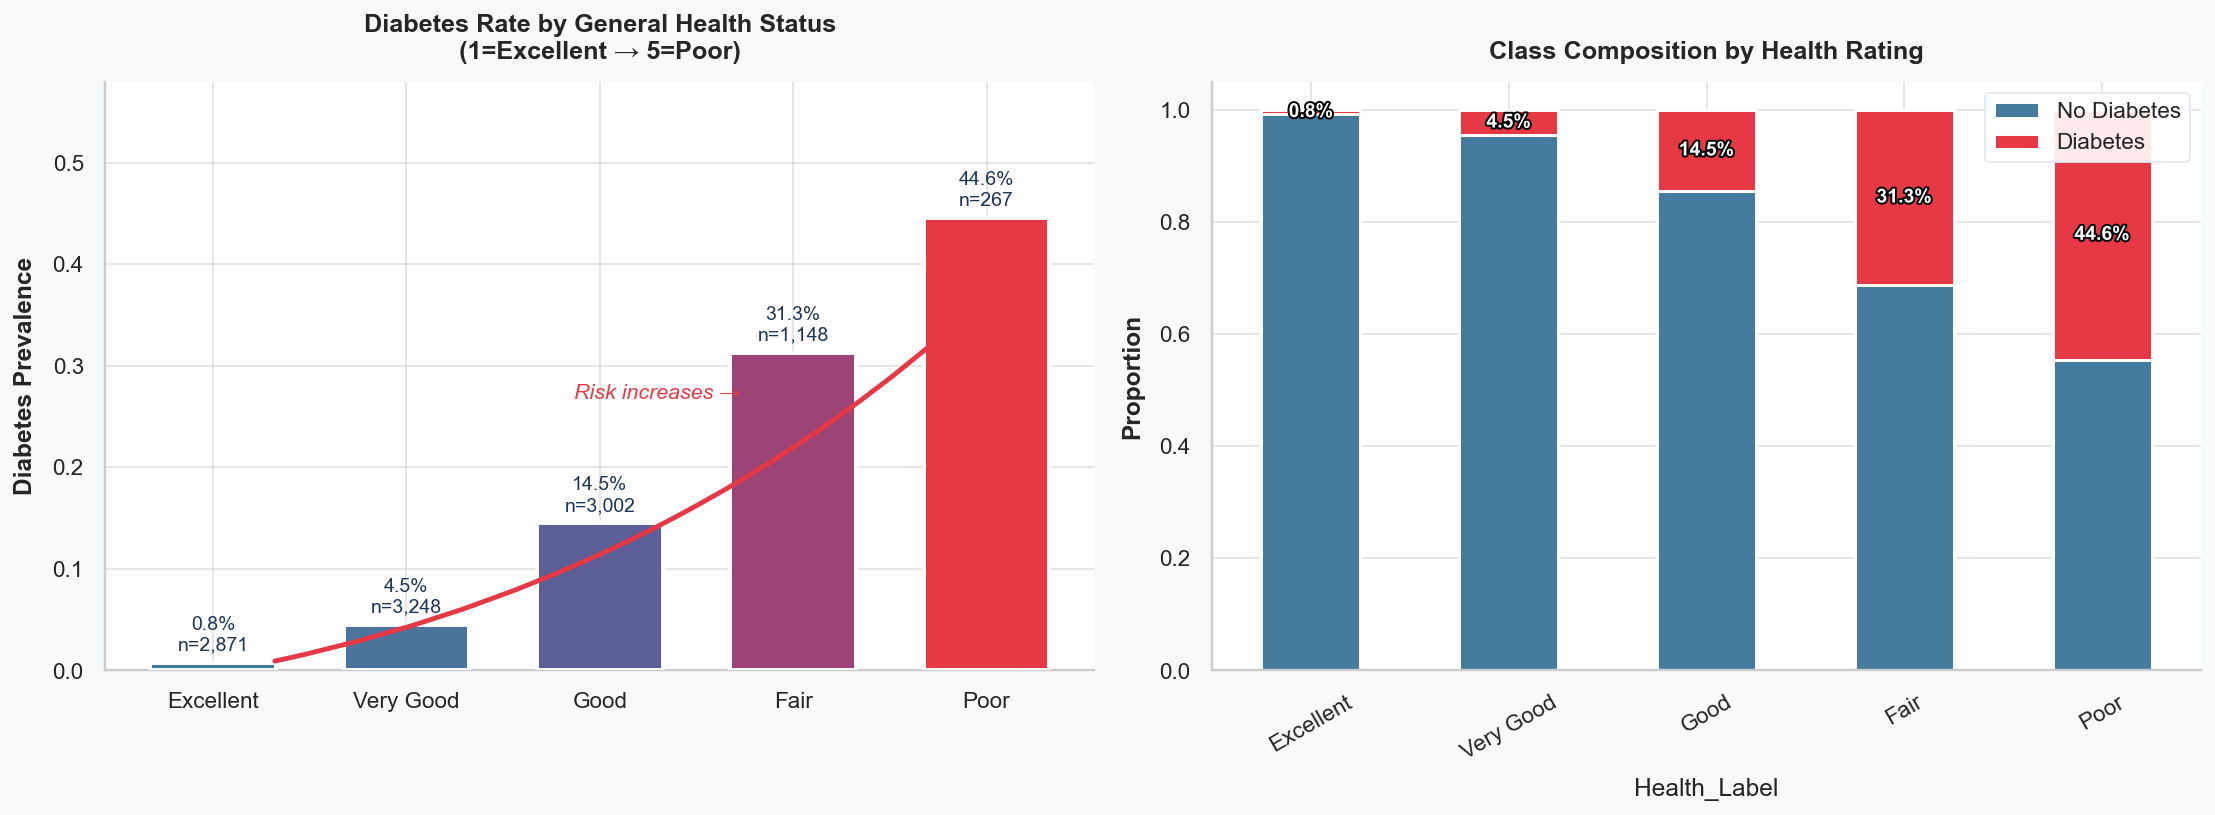


→ Clear monotonic trend: worse self-reported health → higher diabetes prevalence.


In [227]:
hosp = load_xpt('hospital_utilization_access_to_care')
hosp = remove_sentinels(hosp)
hosp = hosp.merge(target, on='SEQN', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tmp = hosp[['HUQ010', 'diabetes_class']].dropna()
labels_map = {1: 'Excellent', 2: 'Very Good', 3: 'Good', 4: 'Fair', 5: 'Poor'}
tmp['Health_Label'] = tmp['HUQ010'].map(labels_map)

# ── LEFT: Gradient bar with progressive colour ──
ax = axes[0]
rate = tmp.groupby('HUQ010')['diabetes_class'].agg(['mean', 'count']).reset_index()
rate['label'] = rate['HUQ010'].map(labels_map)
rate = rate.sort_values('HUQ010')

# Create gradient from blue (low risk) → red (high risk)
cmap = LinearSegmentedColormap.from_list('health_risk',
    [COLORS['no_diab'], COLORS['accent'], COLORS['diab']])
norm = plt.Normalize(rate['mean'].min(), rate['mean'].max())
bar_colors = [cmap(norm(v)) for v in rate['mean']]

bars = ax.bar(rate['label'], rate['mean'], color=bar_colors,
              edgecolor='white', linewidth=2, width=0.65, zorder=3)
annotate_bars(ax, bars, counts=rate['count'].values, offset=0.008, fontsize=10)

# Add trend arrow
ax.annotate('', xy=(4.3, rate['mean'].max() * 0.95),
            xytext=(0.3, rate['mean'].min() * 1.1),
            arrowprops=dict(arrowstyle='->', color=COLORS['diab'],
                          lw=2.5, connectionstyle='arc3,rad=0.15'))
ax.text(2.3, rate['mean'].max() * 0.6, 'Risk increases →',
        fontsize=11, fontstyle='italic', color=COLORS['diab'], ha='center')

ax.set_ylabel('Diabetes Prevalence', fontweight='bold')
ax.set_title(f'Diabetes Rate by {nice("HUQ010")}\n(1=Excellent → 5=Poor)',
             fontsize=13, pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, rate['mean'].max() * 1.30)

# ── RIGHT: 100% stacked bar ──
ax2 = axes[1]
ct = pd.crosstab(tmp['Health_Label'], tmp['diabetes_class'], normalize='index')
ct = ct.reindex(['Excellent', 'Very Good', 'Good', 'Fair', 'Poor'])
ct.columns = ['No Diabetes', 'Diabetes']
ct.plot(kind='bar', stacked=True, ax=ax2,
        color=[COLORS['no_diab'], COLORS['diab']], edgecolor='white', linewidth=1.5)
# Add diabetes % labels on bars
for i, (idx, row) in enumerate(ct.iterrows()):
    diab_pct = row['Diabetes']
    ax2.text(i, 1 - diab_pct / 2, f'{diab_pct:.1%}',
             ha='center', va='center', fontsize=10, fontweight='bold', color='white',
             path_effects=[pe.withStroke(linewidth=2, foreground='black')])
ax2.set_ylabel('Proportion', fontweight='bold')
ax2.set_title('Class Composition by Health Rating', fontsize=13, pad=12)
ax2.tick_params(axis='x', rotation=30)
ax2.legend(framealpha=0.9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('Results/exploring/eda_general_health.png', bbox_inches='tight')
plt.show()
print('\n→ Clear monotonic trend: worse self-reported health → higher diabetes prevalence.')

### 3.4 Functioning & Disability
Features: `FNDADI` (adult disability indicator), `FNDAEDI` (enhanced disability indicator)

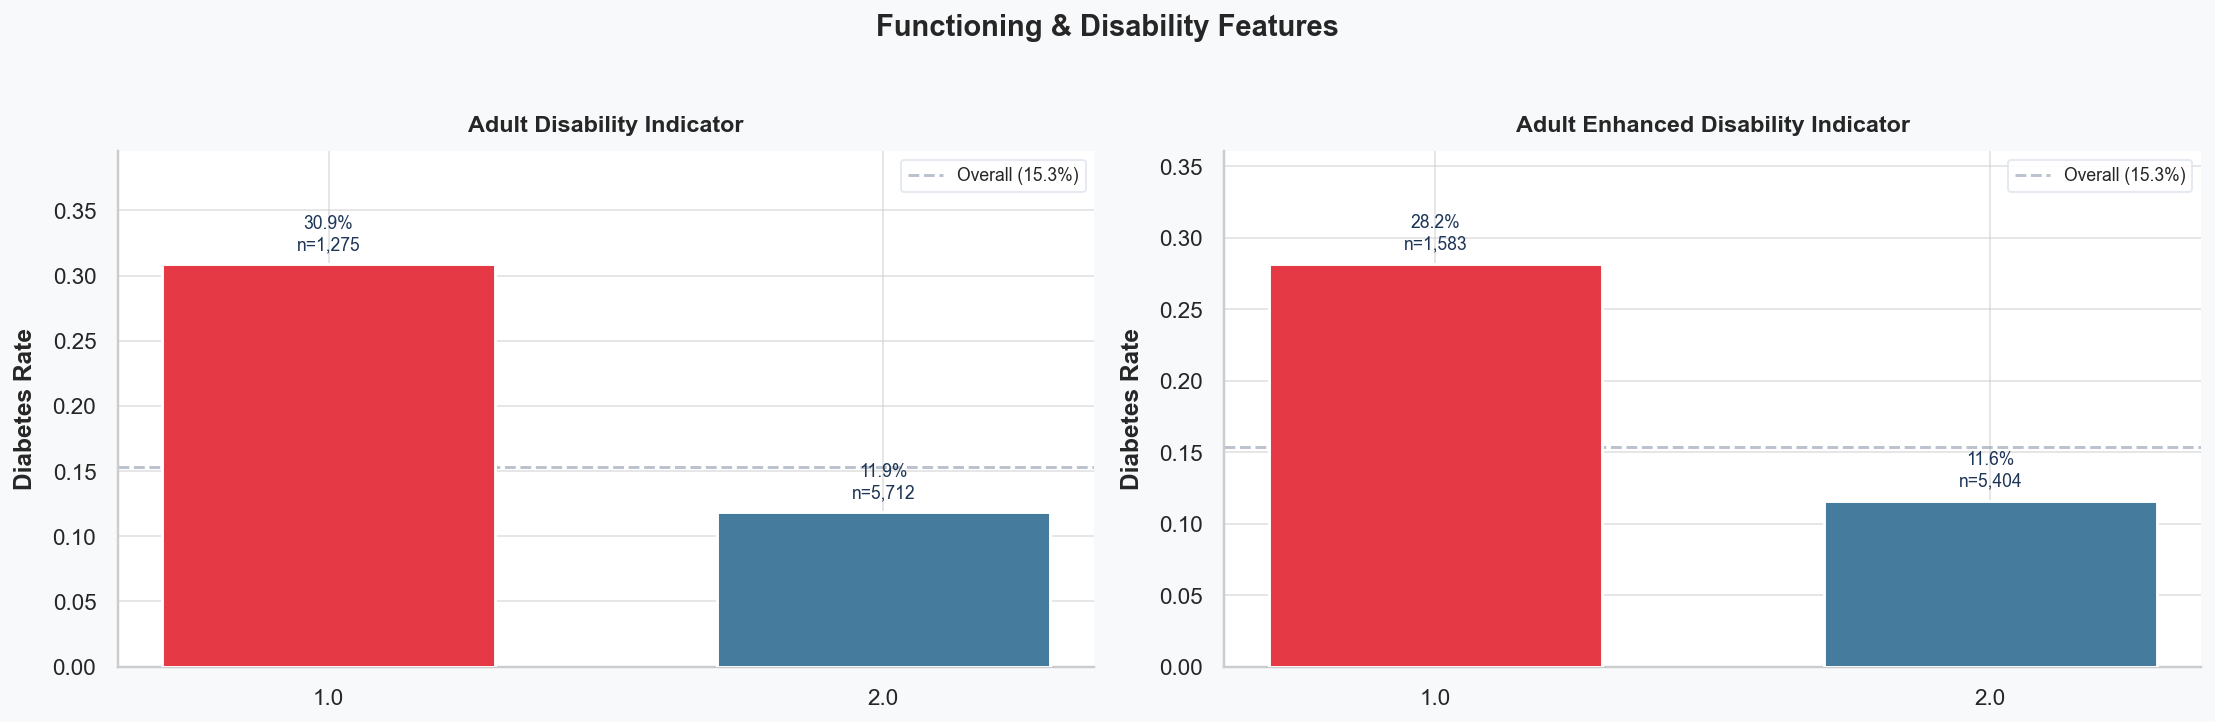

In [228]:
func = load_xpt('functioning')
func = remove_sentinels(func)
func = func.merge(target, on='SEQN', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, col in enumerate(['FNDADI', 'FNDAEDI']):
    ax = axes[i]
    if col not in func.columns:
        ax.text(0.5, 0.5, f'{col} not found', transform=ax.transAxes, ha='center')
        continue
    tmp = func[[col, 'diabetes_class']].dropna()
    rate = tmp.groupby(col)['diabetes_class'].agg(['mean', 'count']).reset_index()

    # Gradient bars
    cmap_fn = LinearSegmentedColormap.from_list('fn', [COLORS['no_diab'], COLORS['accent'], COLORS['diab']])
    norm_fn = plt.Normalize(rate['mean'].min(), rate['mean'].max())
    bar_colors = [cmap_fn(norm_fn(v)) for v in rate['mean']]

    bars = ax.bar(rate[col].astype(str), rate['mean'], color=bar_colors,
                  edgecolor='white', linewidth=1.5, width=0.6, zorder=3)
    annotate_bars(ax, bars, counts=rate['count'].values, offset=0.008, fontsize=9)
    ax.axhline(tmp['diabetes_class'].mean(), ls='--', color=COLORS['neutral'],
               alpha=0.6, label=f'Overall ({tmp["diabetes_class"].mean():.1%})')
    ax.set_title(nice(col), fontsize=12, pad=10)
    ax.set_ylabel('Diabetes Rate', fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, rate['mean'].max() * 1.28)

plt.suptitle('Functioning & Disability Features', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('Results/exploring/eda_functioning.png', bbox_inches='tight')
plt.show()

### 3.5 Mental Health (PHQ-9 Depression Screener)
Features: `DPQ020` (depressed mood), `DPQ030` (sleep problems), `DPQ040` (fatigue), `DPQ050` (appetite changes)  
Scale: 0 = Not at all, 1 = Several days, 2 = More than half, 3 = Nearly every day

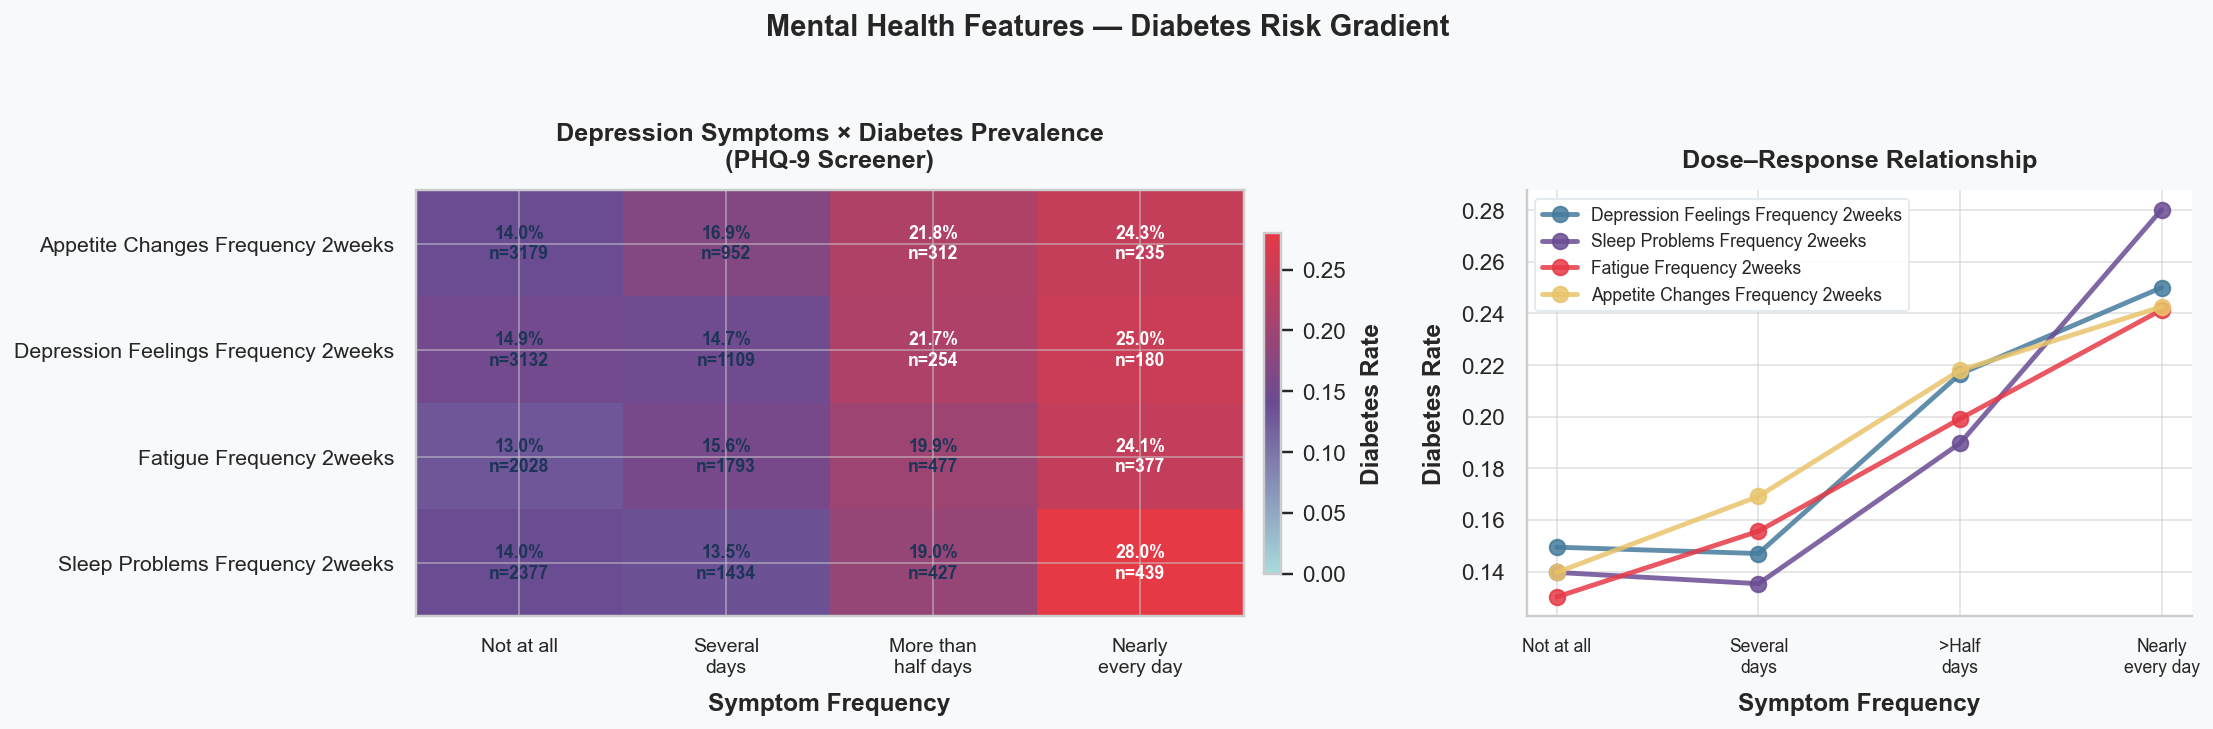

→ All four PHQ-9 symptoms show clear dose–response: higher frequency → higher diabetes prevalence.


In [229]:
mh = load_xpt('mental_health_depression_screener')
mh = remove_sentinels(mh)
mh = mh.merge(target, on='SEQN', how='inner')

mh_features = ['DPQ020', 'DPQ030', 'DPQ040', 'DPQ050']

scale_labels = {0: 'Not at all', 1: 'Several\ndays', 2: 'More than\nhalf days', 3: 'Nearly\nevery day'}

# ── Heatmap-style grid: rows = features, cols = PHQ score, colour = diabetes rate ──
heat_data = []
for col in mh_features:
    if col not in mh.columns:
        continue
    tmp = mh[[col, 'diabetes_class']].dropna()
    for val in sorted(tmp[col].unique()):
        subset = tmp[tmp[col] == val]
        heat_data.append({
            'Feature': nice(col), 'Score': int(val),
            'Rate': subset['diabetes_class'].mean(),
            'Count': len(subset),
        })

heat_df = pd.DataFrame(heat_data)
heat_pivot = heat_df.pivot(index='Feature', columns='Score', values='Rate')
heat_count = heat_df.pivot(index='Feature', columns='Score', values='Count')

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1.5, 1]})

# ── LEFT: Annotated heatmap ──
ax = axes[0]
cmap_mh = LinearSegmentedColormap.from_list('mh_risk',
    [COLORS['light'], COLORS['accent'], COLORS['diab']])
im = ax.imshow(heat_pivot.values, cmap=cmap_mh, aspect='auto', vmin=0)

ax.set_xticks(range(len(heat_pivot.columns)))
ax.set_xticklabels([scale_labels.get(c, str(c)) for c in heat_pivot.columns], fontsize=10)
ax.set_yticks(range(len(heat_pivot.index)))
ax.set_yticklabels(heat_pivot.index, fontsize=11)

# Annotate each cell
for i in range(len(heat_pivot.index)):
    for j in range(len(heat_pivot.columns)):
        val = heat_pivot.iloc[i, j]
        cnt = heat_count.iloc[i, j]
        if pd.notna(val):
            text_color = 'white' if val > 0.2 else COLORS['dark']
            ax.text(j, i, f'{val:.1%}\nn={int(cnt)}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color=text_color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Diabetes Rate', fontweight='bold')
ax.set_title('Depression Symptoms × Diabetes Prevalence\n(PHQ-9 Screener)', fontsize=13, pad=12)
ax.set_xlabel('Symptom Frequency', fontweight='bold')

# ── RIGHT: Radar / line chart showing dose-response ──
ax2 = axes[1]
radar_colors = [COLORS['no_diab'], COLORS['accent'], COLORS['diab'], COLORS['warn']]
for idx, col in enumerate(mh_features):
    if col not in mh.columns:
        continue
    tmp = mh[[col, 'diabetes_class']].dropna()
    rate = tmp.groupby(col)['diabetes_class'].mean()
    ax2.plot(rate.index, rate.values, 'o-', label=nice(col),
             linewidth=2.5, markersize=8, color=radar_colors[idx], alpha=0.85)

ax2.set_xticks([0, 1, 2, 3])
ax2.set_xticklabels(['Not at all', 'Several\ndays', '>Half\ndays', 'Nearly\nevery day'], fontsize=9)
ax2.set_ylabel('Diabetes Rate', fontweight='bold')
ax2.set_xlabel('Symptom Frequency', fontweight='bold')
ax2.set_title('Dose–Response Relationship', fontsize=13, pad=12)
ax2.legend(fontsize=9, framealpha=0.9)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Mental Health Features — Diabetes Risk Gradient', fontsize=15, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('Results/exploring/eda_mental_health.png', bbox_inches='tight')
plt.show()

print('→ All four PHQ-9 symptoms show clear dose–response: higher frequency → higher diabetes prevalence.')

### 3.6 Medical Conditions (Derived Binary Features)
Comorbidity flags: `KidneyFailure_Ever`, `Liver_Ever`, `Liver_Current`, `Asthma_Ever`, `Asthma_Current`, `Thyroid_Ever`, `Thyroid_Current`, `Gallstones_Ever`, `Gallbladder_Removed`, `Cancer_Ever`  

Also includes pruned features: `Arthritis_Ever`, `MCQ160B/C/E` (CHF, CHD, Heart attack) — shown to demonstrate low importance.

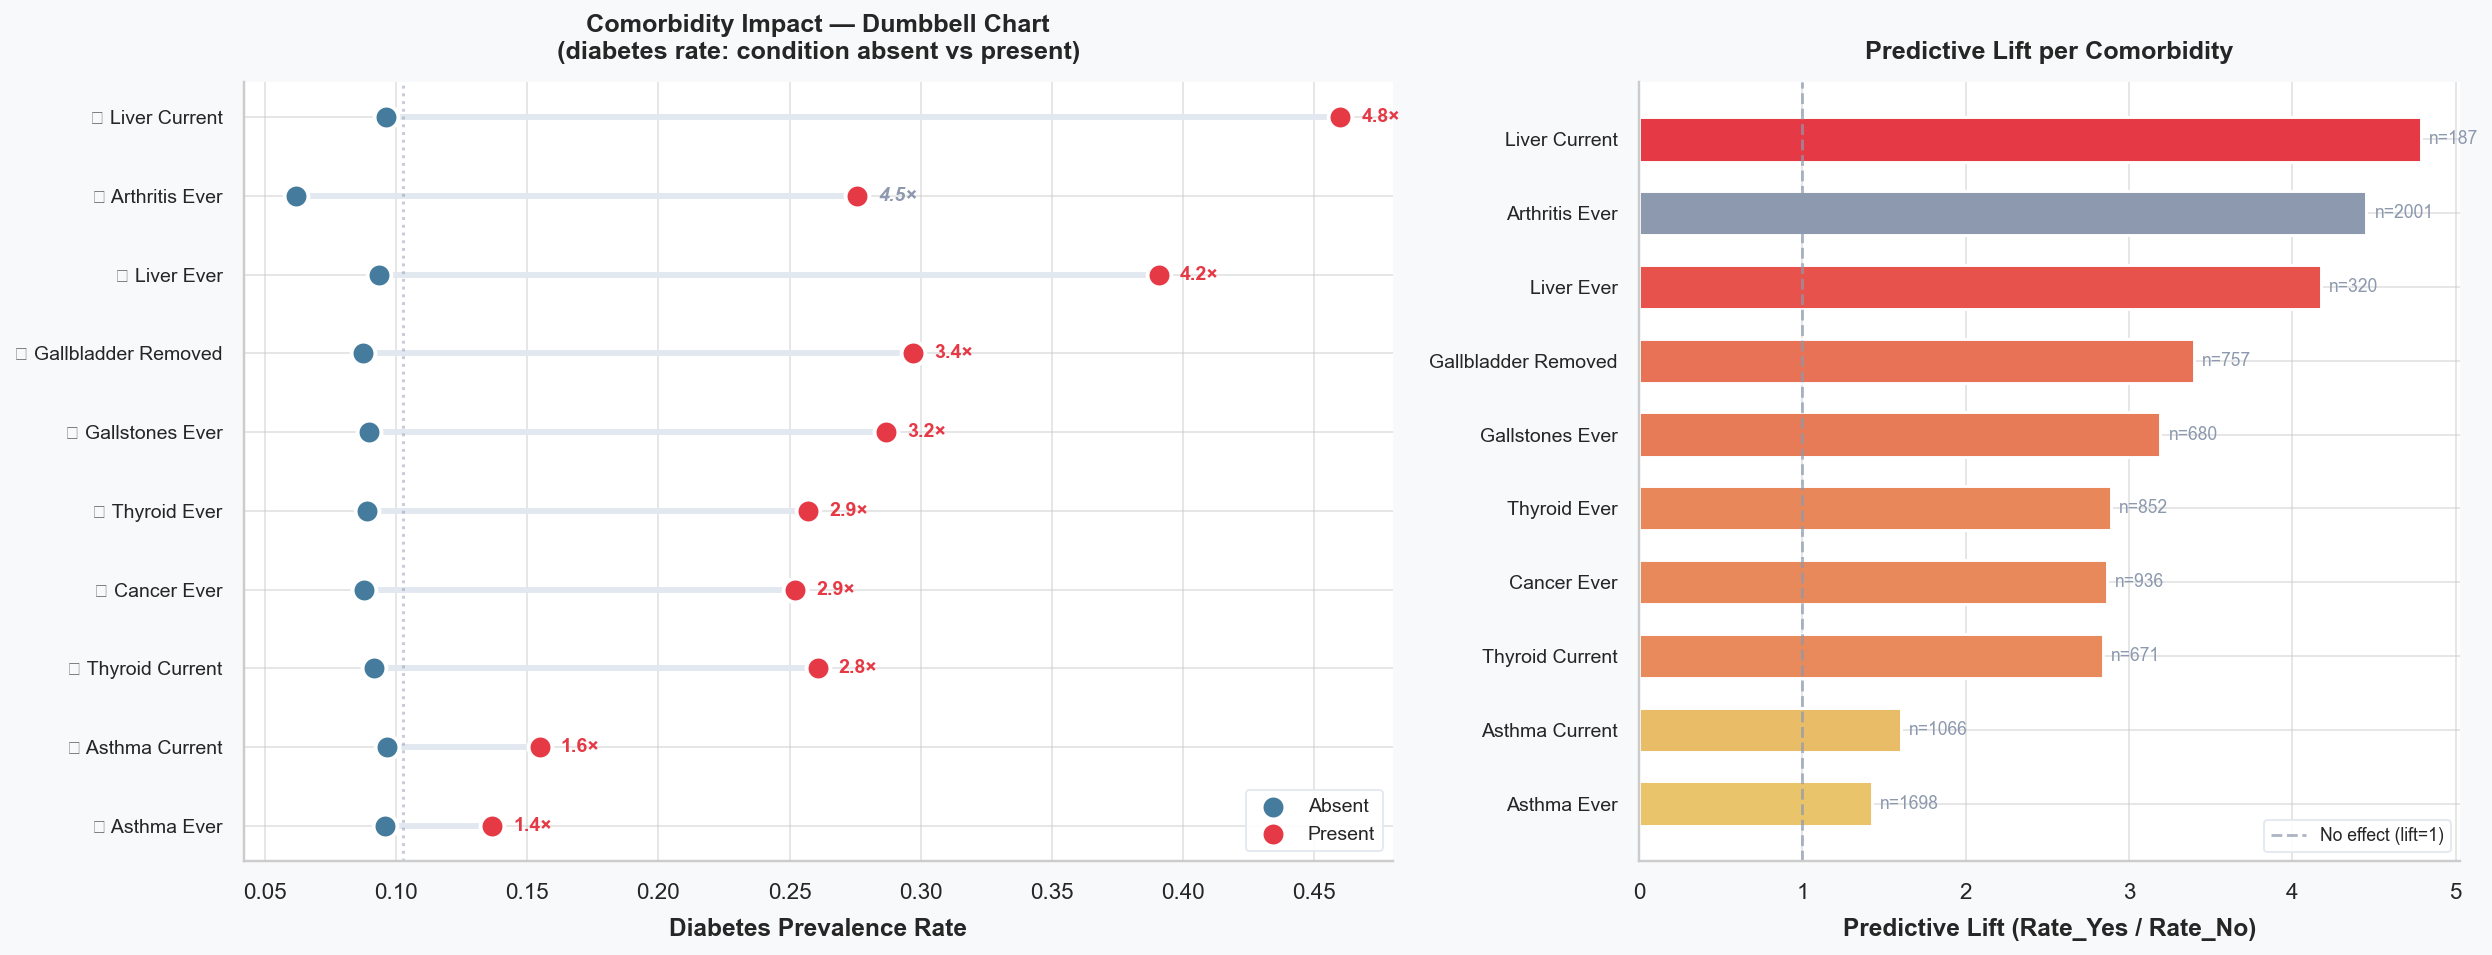


             Feature  Rate_Yes  Rate_No   Lift  n_positive
        Asthma_Ever    0.1366   0.0960 1.4233        1698
     Asthma_Current    0.1548   0.0967 1.6012        1066
    Thyroid_Current    0.2608   0.0918 2.8415         671
        Cancer_Ever    0.2521   0.0880 2.8663         936
       Thyroid_Ever    0.2570   0.0890 2.8895         852
    Gallstones_Ever    0.2868   0.0898 3.1920         680
Gallbladder_Removed    0.2972   0.0875 3.3976         757
         Liver_Ever    0.3906   0.0935 4.1767         320
     Arthritis_Ever    0.2759   0.0619 4.4539        2001
      Liver_Current    0.4599   0.0961 4.7861         187


In [230]:
mc = load_xpt('medical_conditions')
mc = remove_sentinels(mc)
mc = mc.merge(target, on='SEQN', how='inner')

# Derive all binary flags
mc['Asthma_Ever'] = (mc.get('MCQ010', pd.Series(dtype=float)) == 1).astype(int)
mc['Asthma_Current'] = ((mc.get('MCQ010', pd.Series(dtype=float)) == 1) &
                        (mc.get('MCQ035', pd.Series(dtype=float)) == 1)).astype(int)
mc['Arthritis_Ever'] = (mc.get('MCQ160A', pd.Series(dtype=float)) == 1).astype(int)
mc['Thyroid_Ever'] = (mc.get('MCQ160M', pd.Series(dtype=float)) == 1).astype(int)
mc['Thyroid_Current'] = ((mc.get('MCQ160M', pd.Series(dtype=float)) == 1) &
                         (mc.get('MCQ170M', pd.Series(dtype=float)) == 1)).astype(int)
mc['Liver_Ever'] = (mc.get('MCQ160L', pd.Series(dtype=float)) == 1).astype(int)
mc['Liver_Current'] = ((mc.get('MCQ160L', pd.Series(dtype=float)) == 1) &
                       (mc.get('MCQ170L', pd.Series(dtype=float)) == 1)).astype(int)
mc['Cancer_Ever'] = (mc.get('MCQ220', pd.Series(dtype=float)) == 1).astype(int)
mc['Gallstones_Ever'] = (mc.get('MCQ550', pd.Series(dtype=float)) == 1).astype(int)
mc['Gallbladder_Removed'] = (mc.get('MCQ560', pd.Series(dtype=float)) == 1).astype(int)

cond_features = [
    'KidneyFailure_Ever', 'Liver_Ever', 'Liver_Current',
    'Asthma_Ever', 'Asthma_Current',
    'Thyroid_Ever', 'Thyroid_Current',
    'Gallstones_Ever', 'Gallbladder_Removed', 'Cancer_Ever',
    'Arthritis_Ever',
]
cond_features = [c for c in cond_features if c in mc.columns]

rates = []
for col in cond_features:
    tmp = mc[[col, 'diabetes_class']].dropna()
    r_yes = tmp[tmp[col] == 1]['diabetes_class'].mean()
    r_no  = tmp[tmp[col] == 0]['diabetes_class'].mean()
    n_yes = (tmp[col] == 1).sum()
    rates.append({'Feature': col, 'Rate_Yes': r_yes, 'Rate_No': r_no,
                  'Lift': r_yes / (r_no + 1e-9), 'n_positive': n_yes})

rates_df = pd.DataFrame(rates).sort_values('Lift', ascending=True)

# ── Professional Dumbbell Chart with Lift Annotations ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1.4, 1]})

# LEFT: Dumbbell chart
ax = axes[0]
y_pos = np.arange(len(rates_df))

# Connecting lines
for i, (_, row) in enumerate(rates_df.iterrows()):
    ax.plot([row['Rate_No'], row['Rate_Yes']], [i, i],
            color=COLORS['grid'], linewidth=3, zorder=1)

# Dots
ax.scatter(rates_df['Rate_No'], y_pos, s=150, color=COLORS['no_diab'],
           edgecolors='white', linewidths=2, zorder=3, label='Absent')
ax.scatter(rates_df['Rate_Yes'], y_pos, s=150, color=COLORS['diab'],
           edgecolors='white', linewidths=2, zorder=3, label='Present')

# Lift labels
for i, (_, row) in enumerate(rates_df.iterrows()):
    is_pruned = row['Feature'] == 'Arthritis_Ever'
    color = COLORS['neutral'] if is_pruned else COLORS['diab']
    style = 'italic' if is_pruned else 'normal'
    ax.annotate(f'{row["Lift"]:.1f}×',
                xy=(max(row['Rate_Yes'], row['Rate_No']) + 0.008, i),
                fontsize=10, fontweight='bold', color=color,
                fontstyle=style, va='center')

feat_labels = []
for f in rates_df['Feature']:
    label = nice(f)
    if f == '':
        feat_labels.append(f'✗ {label}')
    else:
        feat_labels.append(f'✓ {label}')

ax.set_yticks(y_pos)
ax.set_yticklabels(feat_labels, fontsize=10)
ax.set_xlabel('Diabetes Prevalence Rate', fontweight='bold')
ax.set_title('Comorbidity Impact — Dumbbell Chart\n(diabetes rate: condition absent vs present)', fontsize=13, pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.axvline(mc['diabetes_class'].mean(), ls=':', color=COLORS['neutral'], alpha=0.5)

# RIGHT: Lift bar chart with colour gradient
ax2 = axes[1]
cmap_lift = LinearSegmentedColormap.from_list('lift', [COLORS['warn'], COLORS['diab']])
norm_lift = plt.Normalize(rates_df['Lift'].min(), rates_df['Lift'].max())
bar_colors = [COLORS['neutral'] if f == 'Arthritis_Ever'
              else cmap_lift(norm_lift(l))
              for f, l in zip(rates_df['Feature'], rates_df['Lift'])]

bars = ax2.barh(y_pos, rates_df['Lift'], color=bar_colors,
                edgecolor='white', linewidth=1.5, height=0.6)
ax2.axvline(1, ls='--', color=COLORS['neutral'], alpha=0.7, label='No effect (lift=1)')
ax2.set_yticks(y_pos)
ax2.set_yticklabels([nice(f) for f in rates_df['Feature']], fontsize=10)
ax2.set_xlabel('Predictive Lift (Rate_Yes / Rate_No)', fontweight='bold')
ax2.set_title('Predictive Lift per Comorbidity', fontsize=13, pad=12)
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

# Annotate n values
for i, (bar, n) in enumerate(zip(bars, rates_df['n_positive'])):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'n={n}', va='center', fontsize=9, color=COLORS['neutral'])

plt.tight_layout()
plt.savefig('Results/exploring/eda_medical_conditions.png', bbox_inches='tight')
plt.show()

print('\n', rates_df[['Feature', 'Rate_Yes', 'Rate_No', 'Lift', 'n_positive']].to_string(index=False))

### 3.7 Kidney Conditions
Features: `KIQ005` (kidney stones), `KIQ044` (urinary incontinence), `KIQ481` (bowel incontinence)

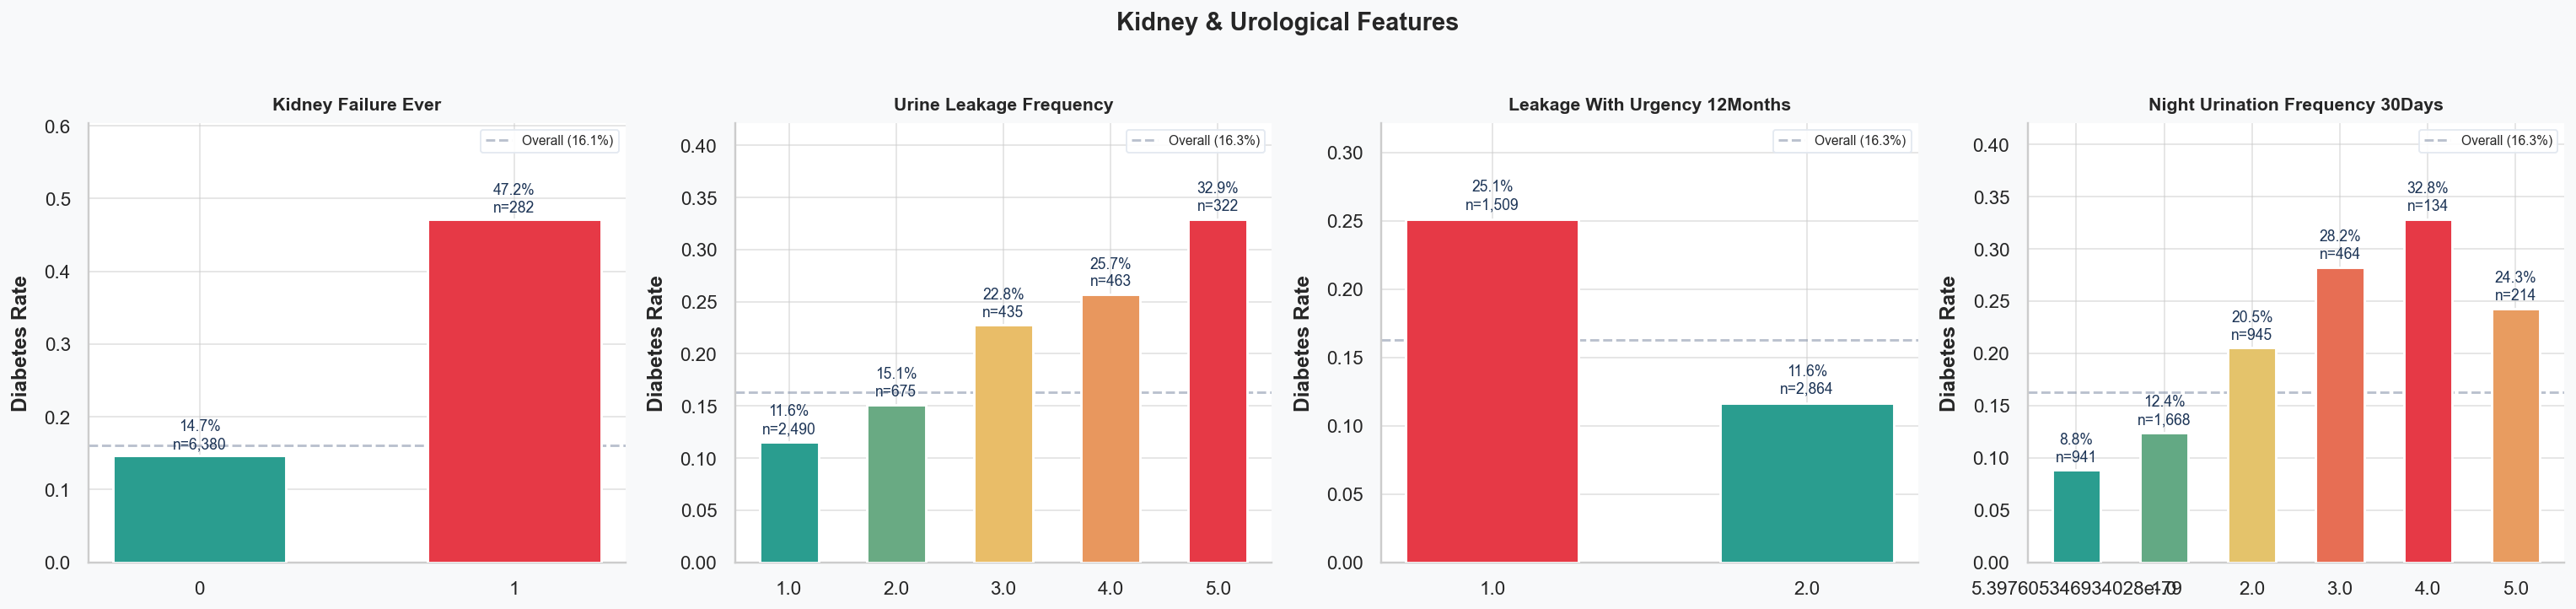

In [231]:
kid = load_xpt('kidney_condition_urology')
kid = remove_sentinels(kid)
kid = kid.merge(target, on='SEQN', how='inner')

if 'KIQ022' in kid.columns:
    kid['KidneyFailure_Ever'] = (kid['KIQ022'] == 1).astype(int)

kid_features = ['KidneyFailure_Ever', 'KIQ005', 'KIQ044', 'KIQ481']

avail = [k for k in kid_features if k in kid.columns]
ncols = len(avail)
fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 5))
if ncols == 1:
    axes = [axes]

for i, col in enumerate(avail):
    ax = axes[i]
    tmp = kid[[col, 'diabetes_class']].dropna()
    rate = tmp.groupby(col)['diabetes_class'].agg(['mean', 'count']).reset_index()

    cmap_k = LinearSegmentedColormap.from_list('kid',
        [COLORS['success'], COLORS['warn'], COLORS['diab']])
    norm_k = plt.Normalize(rate['mean'].min(), rate['mean'].max())
    bar_colors = [cmap_k(norm_k(v)) for v in rate['mean']]

    bars = ax.bar(rate[col].astype(str), rate['mean'], color=bar_colors,
                  edgecolor='white', linewidth=1.5, width=0.55, zorder=3)
    annotate_bars(ax, bars, counts=rate['count'].values, offset=0.005, fontsize=9)
    ax.axhline(tmp['diabetes_class'].mean(), ls='--', color=COLORS['neutral'],
               alpha=0.6, label=f'Overall ({tmp["diabetes_class"].mean():.1%})')
    ax.set_title(nice(col), fontsize=11, pad=8)
    ax.set_ylabel('Diabetes Rate', fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, rate['mean'].max() * 1.28)

plt.suptitle('Kidney & Urological Features', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('Results/exploring/eda_kidney.png', bbox_inches='tight')
plt.show()

### 3.8 Oral Health
Feature: `OHQ845` (self-rating of oral health, 1=Excellent → 5=Poor)

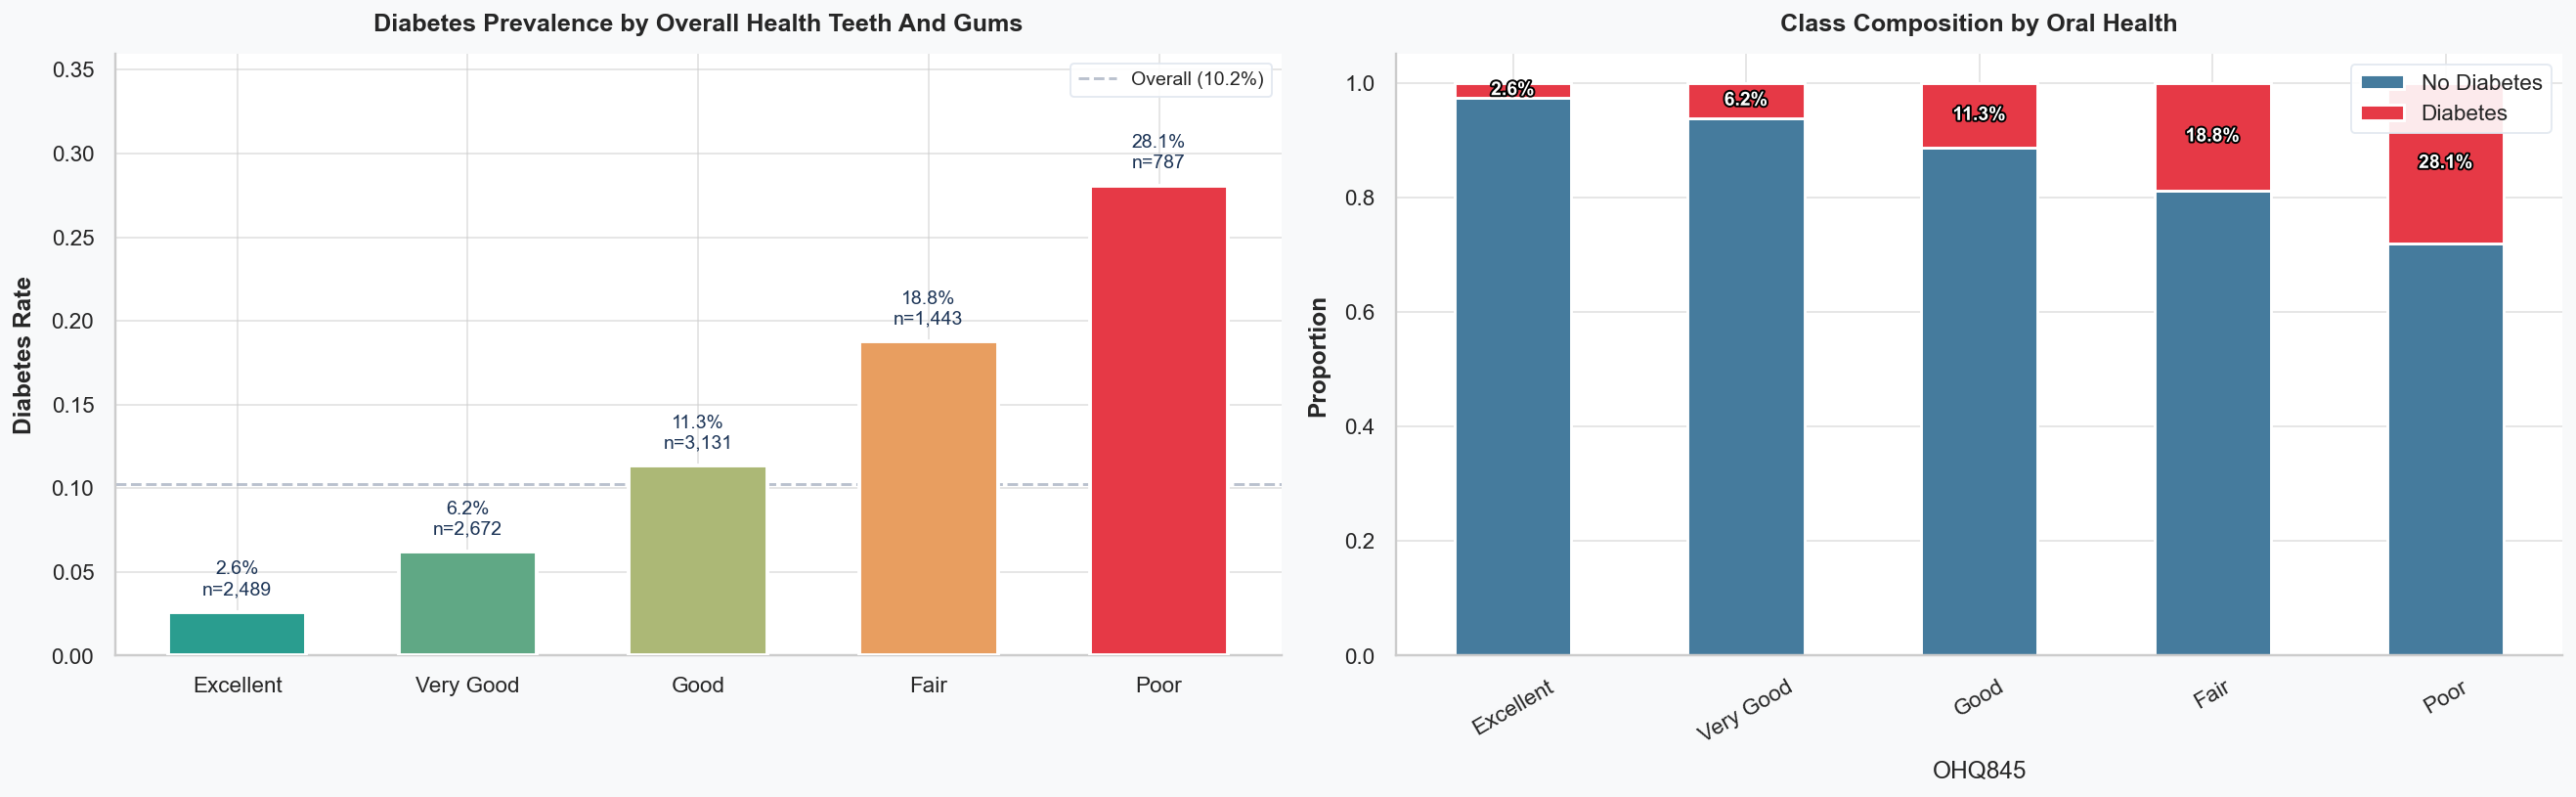

→ Worse oral health strongly associated with higher diabetes rate — supports dental visits as screening opportunity.


In [232]:
oh = load_xpt('oral_health')
oh = remove_sentinels(oh)
oh = oh.merge(target, on='SEQN', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(19, 6))

tmp = oh[['OHQ845', 'diabetes_class']].dropna()
oh_labels = {1: 'Excellent', 2: 'Very Good', 3: 'Good', 4: 'Fair', 5: 'Poor'}

# ── LEFT: Gradient bar ──
ax = axes[0]
rate = tmp.groupby('OHQ845')['diabetes_class'].agg(['mean', 'count']).reset_index()
rate['label'] = rate['OHQ845'].map(oh_labels)
rate = rate.sort_values('OHQ845')

cmap_oh = LinearSegmentedColormap.from_list('oral',
    [COLORS['success'], COLORS['warn'], COLORS['diab']])
norm_oh = plt.Normalize(rate['mean'].min(), rate['mean'].max())
bar_colors = [cmap_oh(norm_oh(v)) for v in rate['mean']]

bars = ax.bar(rate['label'], rate['mean'], color=bar_colors,
              edgecolor='white', linewidth=2, width=0.6, zorder=3)
annotate_bars(ax, bars, counts=rate['count'].values, offset=0.008, fontsize=10)
ax.axhline(tmp['diabetes_class'].mean(), ls='--', color=COLORS['neutral'],
           alpha=0.6, label=f'Overall ({tmp["diabetes_class"].mean():.1%})')
ax.set_ylabel('Diabetes Rate', fontweight='bold')
ax.set_title(f'Diabetes Prevalence by {nice("OHQ845")}', fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, rate['mean'].max() * 1.28)

# ── RIGHT: 100% stacked ──
ax2 = axes[1]
ct = pd.crosstab(tmp['OHQ845'].map(oh_labels), tmp['diabetes_class'], normalize='index')
ct = ct.reindex(['Excellent', 'Very Good', 'Good', 'Fair', 'Poor'])
ct.columns = ['No Diabetes', 'Diabetes']
ct.plot(kind='bar', stacked=True, ax=ax2,
        color=[COLORS['no_diab'], COLORS['diab']], edgecolor='white', linewidth=1.5)
for i, (idx, row) in enumerate(ct.iterrows()):
    diab_pct = row['Diabetes']
    ax2.text(i, 1 - diab_pct / 2, f'{diab_pct:.1%}',
             ha='center', va='center', fontsize=10, fontweight='bold', color='white',
             path_effects=[pe.withStroke(linewidth=2, foreground='black')])
ax2.set_ylabel('Proportion', fontweight='bold')
ax2.set_title('Class Composition by Oral Health', fontsize=13, pad=12)
ax2.tick_params(axis='x', rotation=30)
ax2.legend(framealpha=0.9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('Results/exploring/eda_oral_health.png', bbox_inches='tight')
plt.show()

print('→ Worse oral health strongly associated with higher diabetes rate — '
      'supports dental visits as screening opportunity.')

### 3.9 Smoking
Features: `Ever_Smoker`, `Current_Smoker`, `Former_Smoker`, `SMD650` (cigarettes/day)

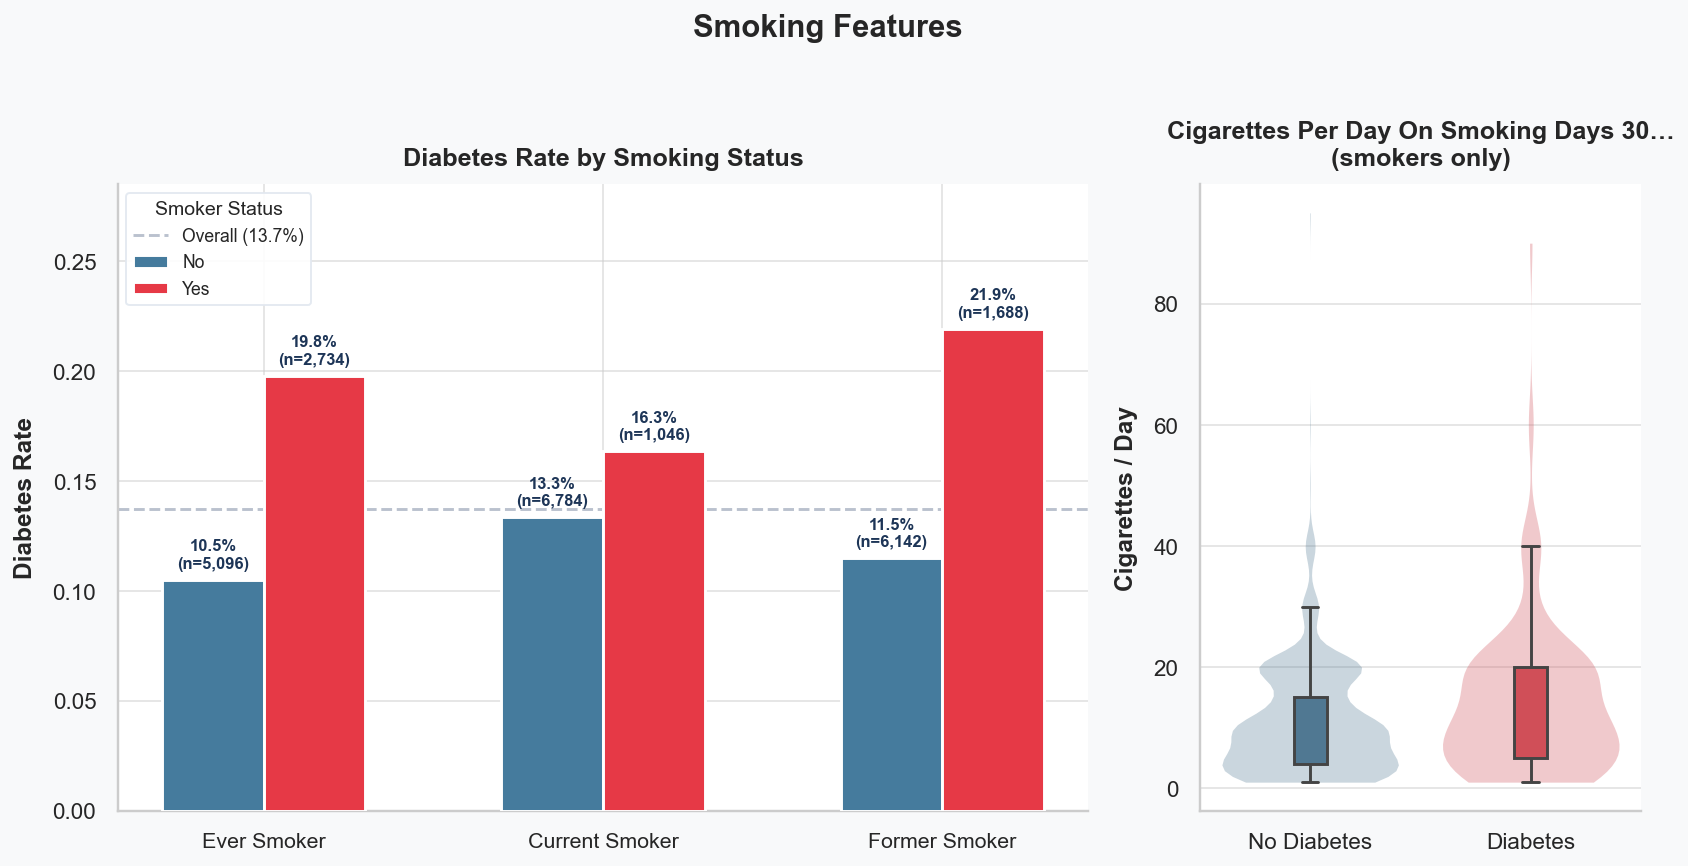

In [233]:
sm = load_xpt('smoking_cigarette_use')
sm = remove_sentinels(sm)
sm = sm.merge(target, on='SEQN', how='inner')

sm['Ever_Smoker'] = (sm.get('SMQ020', pd.Series(dtype=float)) == 1).astype(int)
if 'SMQ040' in sm.columns:
    sm['Current_Smoker'] = ((sm['Ever_Smoker'] == 1) & sm['SMQ040'].isin([1, 2])).astype(int)
    sm['Former_Smoker'] = ((sm['Ever_Smoker'] == 1) & (sm['SMQ040'] == 3)).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [2.2, 1]})

# ── LEFT: Merged grouped bar — all 3 binary smoking features ──
ax = axes[0]
smoke_cols = [c for c in ['Ever_Smoker', 'Current_Smoker', 'Former_Smoker'] if c in sm.columns]
x = np.arange(len(smoke_cols))
bar_w = 0.30

rates_no, rates_yes, n_no, n_yes = [], [], [], []
for col in smoke_cols:
    tmp = sm[[col, 'diabetes_class']].dropna()
    rate = tmp.groupby(col)['diabetes_class'].agg(['mean', 'count']).reset_index()
    rate = rate.sort_values(col)
    rates_no.append(rate.loc[rate[col] == 0, 'mean'].values[0] if 0 in rate[col].values else 0)
    rates_yes.append(rate.loc[rate[col] == 1, 'mean'].values[0] if 1 in rate[col].values else 0)
    n_no.append(int(rate.loc[rate[col] == 0, 'count'].values[0]) if 0 in rate[col].values else 0)
    n_yes.append(int(rate.loc[rate[col] == 1, 'count'].values[0]) if 1 in rate[col].values else 0)

bars_no = ax.bar(x - bar_w/2, rates_no, bar_w, label='No',
                 color=COLORS['no_diab'], edgecolor='white', linewidth=1.5, zorder=3)
bars_yes = ax.bar(x + bar_w/2, rates_yes, bar_w, label='Yes',
                  color=COLORS['diab'], edgecolor='white', linewidth=1.5, zorder=3)

# Annotate
for bar, n in zip(bars_no, n_no):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.1%}\n(n={n:,})', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color=COLORS['dark'])
for bar, n in zip(bars_yes, n_yes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.1%}\n(n={n:,})', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color=COLORS['dark'])

overall = sm['diabetes_class'].mean()
ax.axhline(overall, ls='--', color=COLORS['neutral'], alpha=0.6,
           label=f'Overall ({overall:.1%})')
ax.set_xticks(x)
ax.set_xticklabels([nice(c) for c in smoke_cols], fontsize=11)
ax.set_ylabel('Diabetes Rate', fontweight='bold')
ax.set_title('Diabetes Rate by Smoking Status', fontsize=13, fontweight='bold', pad=10)
ax.legend(title='Smoker Status', fontsize=9, title_fontsize=10,
          framealpha=0.9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(max(rates_no), max(rates_yes)) * 1.30)

# ── RIGHT: SMD650 violin + box overlay ──
if 'SMD650' in sm.columns:
    ax2 = axes[1]
    tmp = sm[['SMD650', 'diabetes_class']].dropna()
    tmp = tmp[tmp['SMD650'] > 0]
    plot_df = tmp.copy()
    plot_df['Class'] = plot_df['diabetes_class'].map({0: 'No Diabetes', 1: 'Diabetes'})
    sns.violinplot(data=plot_df, x='Class', y='SMD650', ax=ax2,
                   palette=PAL_NAMED, inner=None, cut=0, alpha=0.3, linewidth=0)
    sns.boxplot(data=plot_df, x='Class', y='SMD650', ax=ax2,
                palette=PAL_NAMED, width=0.15, linewidth=1.5,
                boxprops=dict(zorder=3), medianprops=dict(color='white', lw=2),
                fliersize=0)
    ax2.set_title(f'{nice("SMD650")}\n(smokers only)', fontsize=13, fontweight='bold', pad=10)
    ax2.set_xlabel('')
    ax2.set_ylabel('Cigarettes / Day', fontweight='bold')
    ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Smoking Features', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('Results/exploring/eda_smoking.png', bbox_inches='tight')
plt.show()

### 3.10 Audiometry
Features: `AUQ054` (general hearing condition), `AUQ101` (difficulty hearing)

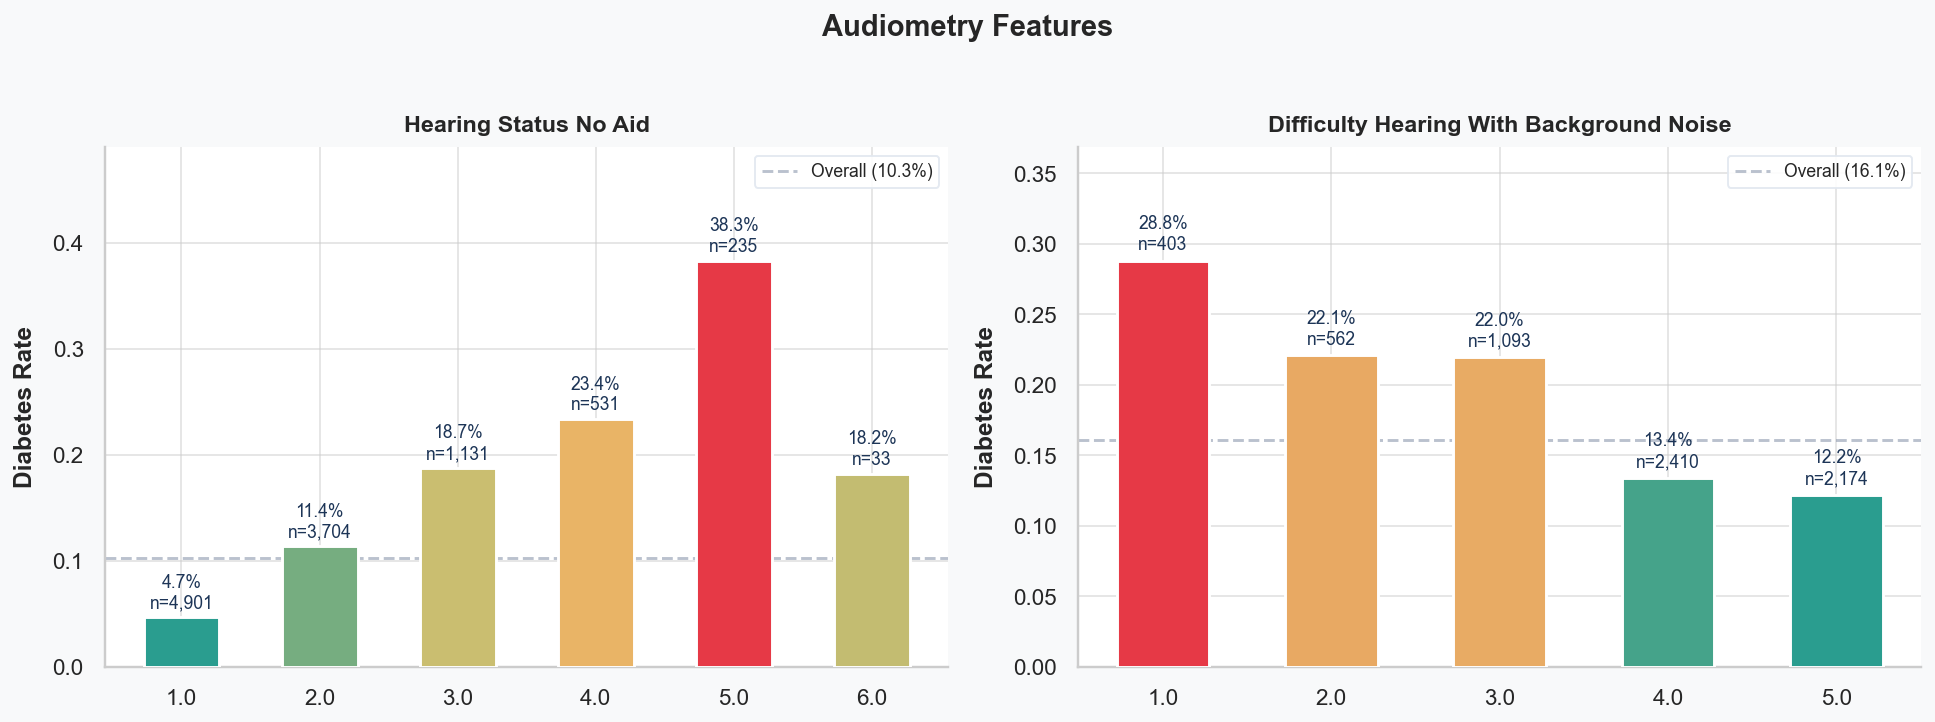

In [234]:
aud = load_xpt('audiometry')
aud = remove_sentinels(aud)
aud = aud.merge(target, on='SEQN', how='inner')

aud_features = ['AUQ054', 'AUQ101']
avail = [k for k in aud_features if k in aud.columns]

fig, axes = plt.subplots(1, len(avail), figsize=(7 * len(avail), 5))
if len(avail) == 1:
    axes = [axes]

for i, col in enumerate(avail):
    ax = axes[i]
    tmp = aud[[col, 'diabetes_class']].dropna()
    rate = tmp.groupby(col)['diabetes_class'].agg(['mean', 'count']).reset_index()

    cmap_a = LinearSegmentedColormap.from_list('aud', [COLORS['success'], COLORS['warn'], COLORS['diab']])
    norm_a = plt.Normalize(rate['mean'].min(), rate['mean'].max())
    bar_colors = [cmap_a(norm_a(v)) for v in rate['mean']]

    bars = ax.bar(rate[col].astype(str), rate['mean'], color=bar_colors,
                  edgecolor='white', linewidth=1.5, width=0.55, zorder=3)
    annotate_bars(ax, bars, counts=rate['count'].values, offset=0.005, fontsize=9)
    ax.axhline(tmp['diabetes_class'].mean(), ls='--', color=COLORS['neutral'],
               alpha=0.6, label=f'Overall ({tmp["diabetes_class"].mean():.1%})')
    ax.set_title(nice(col), fontsize=12, pad=8)
    ax.set_ylabel('Diabetes Rate', fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, rate['mean'].max() * 1.28)

plt.suptitle('Audiometry Features', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('Results/exploring/eda_audiometry.png', bbox_inches='tight')
plt.show()

---
## 4. Correlation Heatmap

Point-biserial / Pearson correlations between all candidate features and the diabetes target.

In [235]:
# Build a combined dataframe with all candidate features + target
# We re-use the individual dataframes already loaded above

all_frames = [target]

# Blood pressure
bp_slim = bp[['SEQN', 'BPQ080', 'BPQ101D', 'Hypertension_Ever', 'Hypertension_OnMedication']].copy()
all_frames.append(bp_slim)

# Weight
wt_cols = ['SEQN', 'WHD010', 'WHD020', 'WHD050', 'WHQ070', 'BMI', 'WeightChange']
wt_slim = wt[[c for c in wt_cols if c in wt.columns]].copy()
all_frames.append(wt_slim)

# Hospital
hosp_slim = hosp[['SEQN', 'HUQ010']].copy() if 'HUQ010' in hosp.columns else None
if hosp_slim is not None:
    all_frames.append(hosp_slim)

# Functioning
fn_cols = ['SEQN'] + [c for c in ['FNDADI', 'FNDAEDI'] if c in func.columns]
if len(fn_cols) > 1:
    all_frames.append(func[fn_cols].copy())

# Mental health
mh_cols = ['SEQN'] + [c for c in ['DPQ020', 'DPQ030', 'DPQ040', 'DPQ050'] if c in mh.columns]
all_frames.append(mh[mh_cols].copy())

# Medical conditions
mc_cols = ['SEQN'] + [c for c in cond_features if c in mc.columns]
all_frames.append(mc[mc_cols].copy())

# Kidney
kid_cols = ['SEQN'] + [c for c in ['KidneyFailure_Ever', 'KIQ005', 'KIQ044', 'KIQ481'] if c in kid.columns]
all_frames.append(kid[kid_cols].copy())

# Oral health
if 'OHQ845' in oh.columns:
    all_frames.append(oh[['SEQN', 'OHQ845']].copy())

# Smoking
sm_cols = ['SEQN'] + [c for c in ['Ever_Smoker', 'Current_Smoker', 'Former_Smoker', 'SMD650'] if c in sm.columns]
all_frames.append(sm[sm_cols].copy())

# Audiometry
aud_cols = ['SEQN'] + [c for c in ['AUQ054', 'AUQ101'] if c in aud.columns]
all_frames.append(aud[aud_cols].copy())

# New features
new_cols = ['SEQN'] + [c for c in new_features if c in new.columns]
all_frames.append(new[new_cols].copy())

# Merge everything
combined = all_frames[0]
for df in all_frames[1:]:
    combined = combined.merge(df, on='SEQN', how='left', suffixes=('', '_dup'))
    dup_cols = [c for c in combined.columns if c.endswith('_dup')]
    combined.drop(columns=dup_cols, inplace=True)

combined.drop(columns=['SEQN'], inplace=True)
print(f'Combined dataset: {combined.shape}')

Combined dataset: (10542, 46)


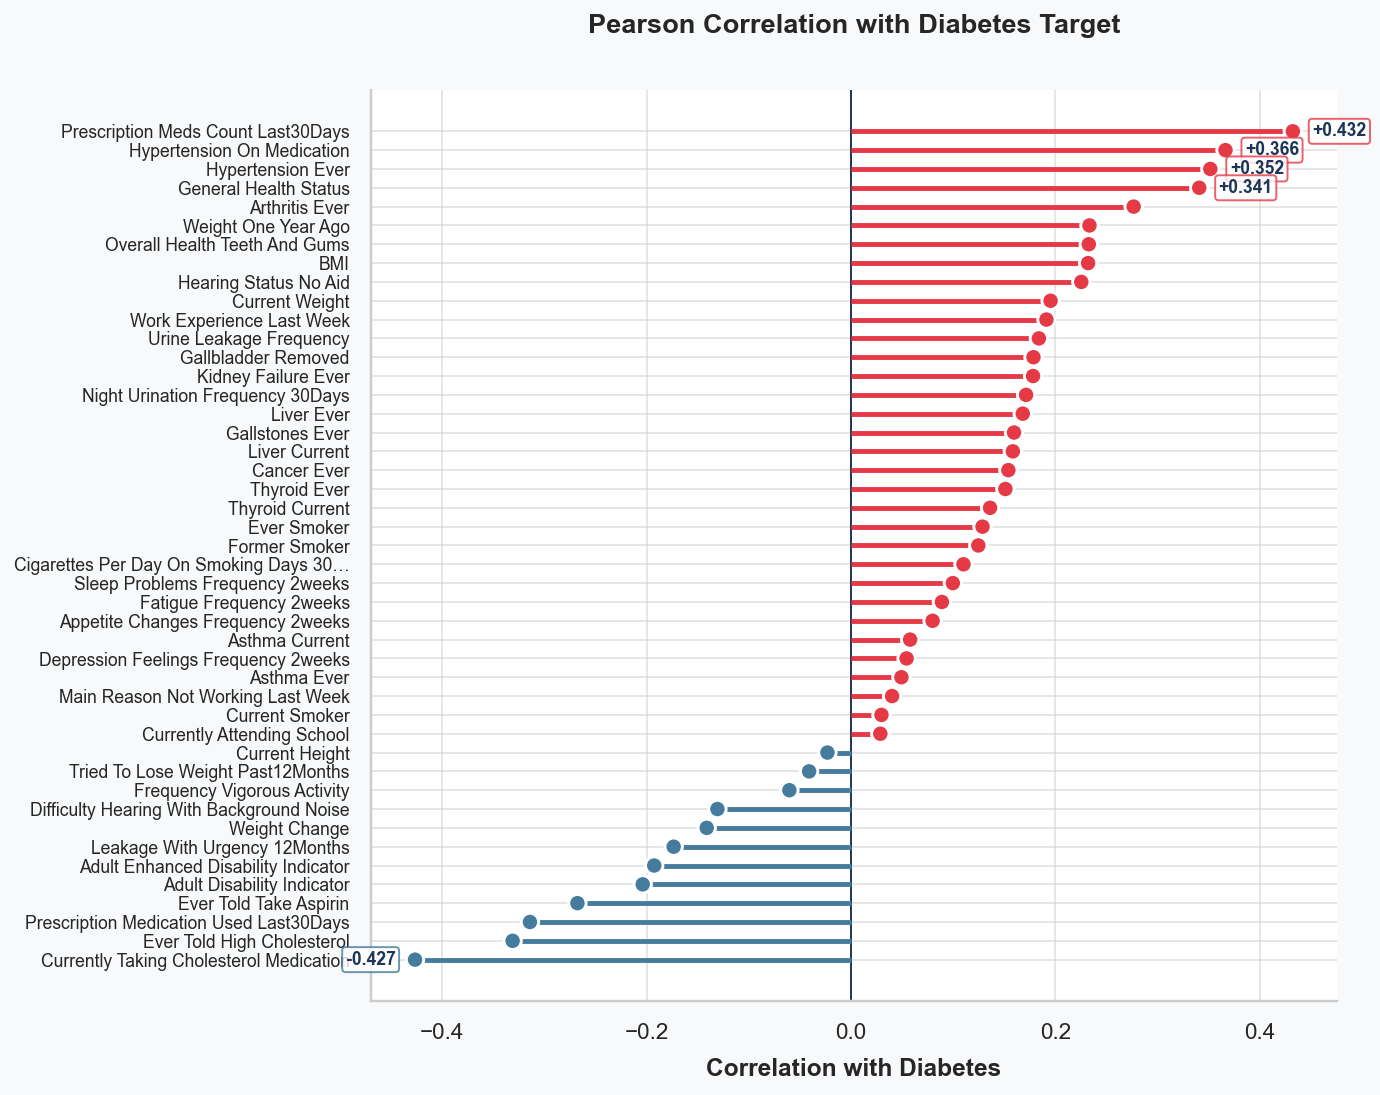


Top 10 positive correlations:
WHD020                      0.1953
AUQ054                      0.2253
BMI                         0.2320
OHQ845                      0.2327
WHD050                      0.2333
Arthritis_Ever              0.2765
HUQ010                      0.3408
Hypertension_Ever           0.3516
Hypertension_OnMedication   0.3665
RXQ050                      0.4324

Top 5 negative correlations:
BPQ101D   -0.4268
BPQ080    -0.3313
RXQ033    -0.3143
RXQ510    -0.2679
FNDADI    -0.2040


In [236]:
# ── Diverging Lollipop: Correlation with Diabetes Target ──
corr_target = combined.corr(numeric_only=True)['diabetes_class'].drop('diabetes_class').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

y_pos = np.arange(len(corr_target))
vals = corr_target.values
names = corr_target.index

# Colour by direction
colors = [COLORS['diab'] if v > 0 else COLORS['no_diab'] for v in vals]

# Horizontal lollipop stems
ax.hlines(y_pos, 0, vals, color=colors, linewidth=2.5, zorder=2)
ax.scatter(vals, y_pos, s=80, color=colors, edgecolors='white', linewidths=1.5, zorder=3)

# Zero line
ax.axvline(0, color=COLORS['dark'], linewidth=1, zorder=1)

# Feature labels — use nice()
ax.set_yticks(y_pos)
ax.set_yticklabels([nice(n) for n in names], fontsize=9)
ax.set_xlabel('Correlation with Diabetes', fontweight='bold')
ax.set_title('Pearson Correlation with Diabetes Target\n',
             fontsize=14, pad=15)

# Annotate top 5 strongest
top_n = 5
strongest = corr_target.abs().nlargest(top_n).index
for feat in strongest:
    idx = list(names).index(feat)
    v = vals[idx]
    ax.annotate(f'{v:+.3f}', xy=(v, idx),
                xytext=(10 if v > 0 else -10, 0), textcoords='offset points',
                fontsize=9, fontweight='bold', color=COLORS['dark'],
                ha='left' if v > 0 else 'right', va='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=colors[idx], alpha=0.8))

ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('Results/exploring/eda_correlation_target.png', bbox_inches='tight')
plt.show()

print('\nTop 10 positive correlations:')
print(corr_target.tail(10).to_string())
print('\nTop 5 negative correlations:')
print(corr_target.head(5).to_string())

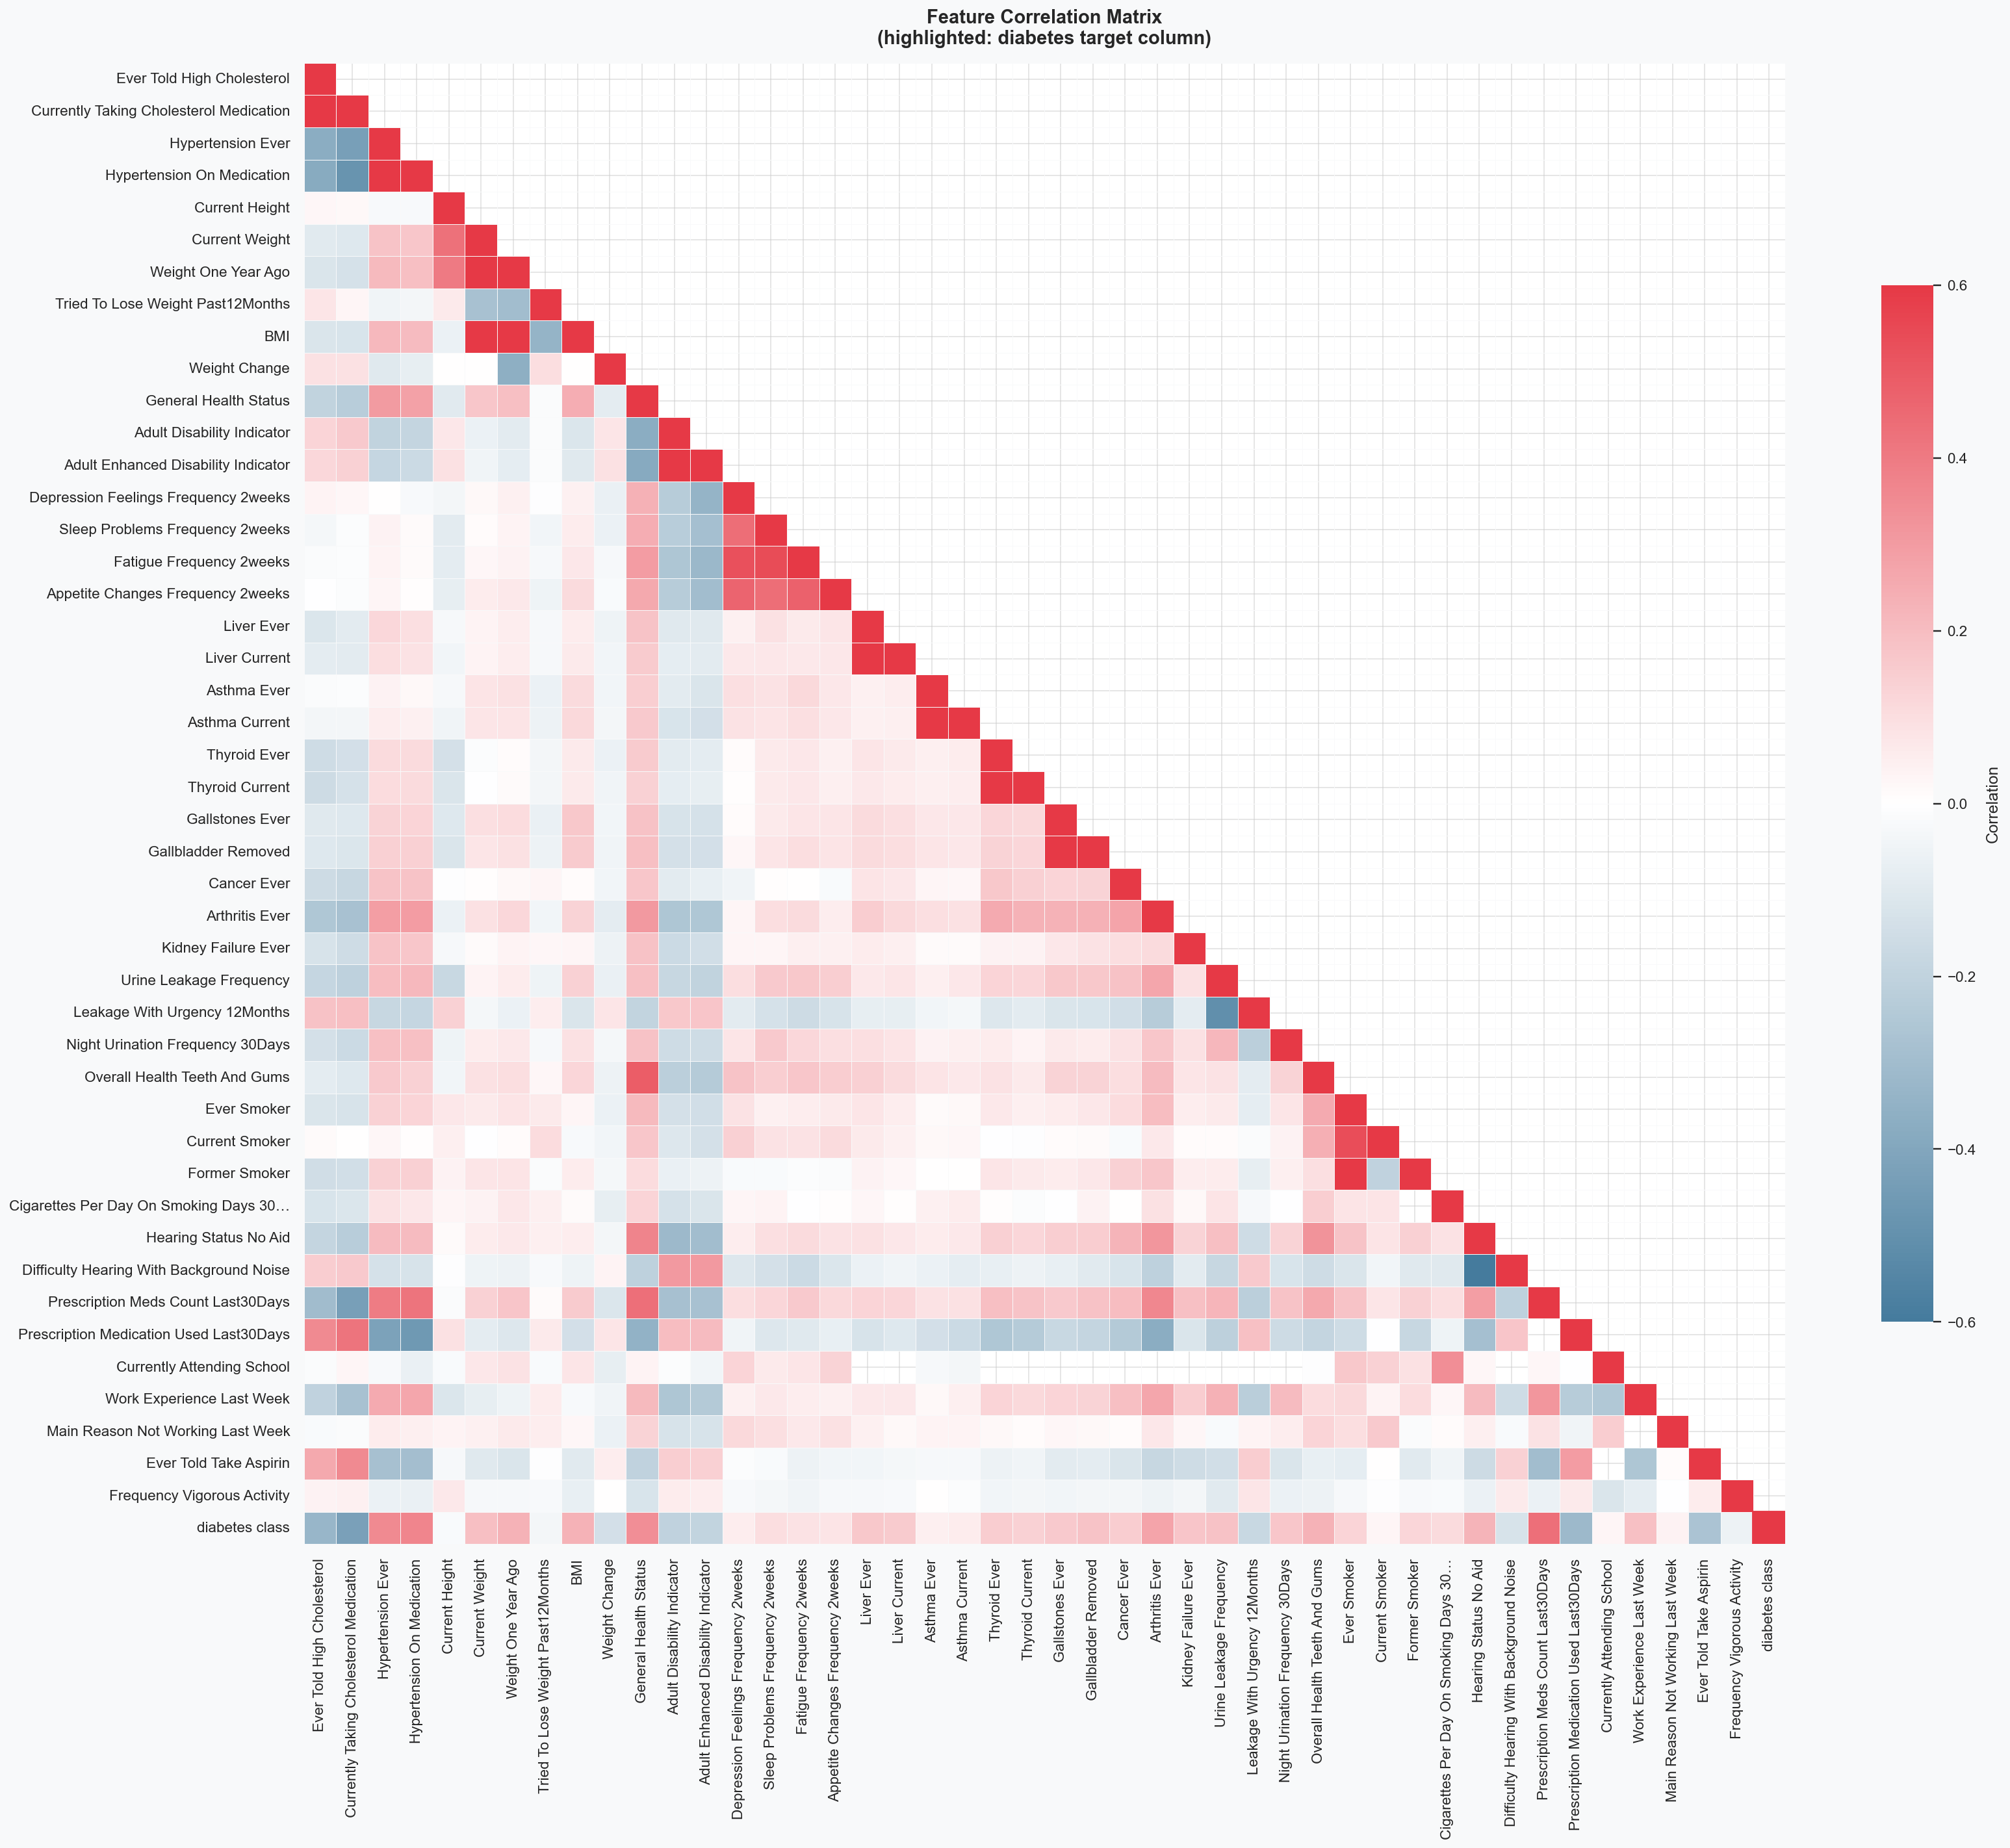

In [237]:
# ── Clustered Heatmap with better colour scheme ──
sel_cols = [c for c in combined.columns if c != 'diabetes_class']
corr_matrix = combined[sel_cols + ['diabetes_class']].corr(numeric_only=True)

# Rename index/columns to nice labels for display
nice_map = {c: nice(c) for c in corr_matrix.columns}
corr_display = corr_matrix.rename(index=nice_map, columns=nice_map)

fig, ax = plt.subplots(figsize=(max(16, len(sel_cols) * 0.55), max(14, len(sel_cols) * 0.45)))
mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)

# Custom diverging colormap
cmap_corr = LinearSegmentedColormap.from_list('corr_custom',
    [COLORS['no_diab'], '#FFFFFF', COLORS['diab']])

sns.heatmap(corr_display, mask=mask, cmap=cmap_corr, center=0, vmin=-0.6, vmax=0.6,
            annot=False, square=True, linewidths=0.3, linecolor=COLORS['bg'],
            ax=ax, cbar_kws={'label': 'Correlation', 'shrink': 0.7})

# Highlight diabetes target row/column
diabetes_idx = list(corr_display.columns).index(nice('diabetes_class'))
ax.add_patch(plt.Rectangle((diabetes_idx, diabetes_idx), 1, len(corr_display) - diabetes_idx,
             fill=False, edgecolor=COLORS['diab'], linewidth=2.5))

ax.set_title('Feature Correlation Matrix\n(highlighted: diabetes target column)',
             fontweight='bold', fontsize=15, pad=15)
plt.tight_layout()
plt.savefig('Results/exploring/eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 5. Statistical Tests

- **Binary / categorical features** → Chi-squared test of independence  
- **Continuous features** → Mann–Whitney U test  

Both test whether a feature's distribution differs significantly between diabetic and non-diabetic groups.

In [238]:
binary_feats = [
    'BPQ080', 'BPQ101D', 'Hypertension_Ever', 'Hypertension_OnMedication',
    'WHQ070', 'HUQ010',
    'KidneyFailure_Ever', 'Liver_Ever', 'Liver_Current',
    'Asthma_Ever', 'Asthma_Current', 'Arthritis_Ever',
    'Thyroid_Ever', 'Thyroid_Current',
    'Gallstones_Ever', 'Gallbladder_Removed', 'Cancer_Ever',
    'KIQ005', 'KIQ044', 'OHQ845',
    'Ever_Smoker', 'Current_Smoker', 'Former_Smoker',
    'AUQ054', 'AUQ101',
    'RXQ050', 'DBQ360', 'RXQ510',
    'FNDADI', 'FNDAEDI',
    'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050',
]

continuous_feats = [
    'WHD010', 'WHD020', 'WHD050', 'BMI', 'WeightChange',
    'SMD650', 'KIQ481',
    'RXQ033', 'OCD150', 'OCQ383', 'PAD810Q',
]

results = []

# Chi-squared for categorical/ordinal features
for col in binary_feats:
    if col not in combined.columns:
        continue
    tmp = combined[[col, 'diabetes_class']].dropna()
    if tmp[col].nunique() < 2:
        continue
    ct = pd.crosstab(tmp[col], tmp['diabetes_class'])
    chi2, p, dof, _ = chi2_contingency(ct)
    # Cramér's V
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    results.append({'Feature': col, 'Test': 'Chi²', 'Statistic': chi2,
                    'p-value': p, 'Effect Size': v, 'n': len(tmp)})

# Mann-Whitney for continuous features
for col in continuous_feats:
    if col not in combined.columns:
        continue
    tmp = combined[[col, 'diabetes_class']].dropna()
    g0 = tmp[tmp['diabetes_class'] == 0][col]
    g1 = tmp[tmp['diabetes_class'] == 1][col]
    if len(g0) < 5 or len(g1) < 5:
        continue
    u, p = mannwhitneyu(g0, g1, alternative='two-sided')
    # Effect size: rank-biserial r = 1 - 2U/(n0*n1)
    r = 1 - (2 * u) / (len(g0) * len(g1))
    results.append({'Feature': col, 'Test': 'Mann-Whitney U', 'Statistic': u,
                    'p-value': p, 'Effect Size': abs(r), 'n': len(tmp)})

stat_df = pd.DataFrame(results).sort_values('p-value')
stat_df['Significant (p<0.05)'] = stat_df['p-value'] < 0.05

print(stat_df.to_string(index=False))

                  Feature           Test    Statistic  p-value  Effect Size     n  Significant (p<0.05)
                   HUQ010           Chi²    1348.4438   0.0000       0.3577 10536                  True
                  BPQ101D           Chi²    1327.5980   0.0000       0.4264  7303                  True
                   RXQ033 Mann-Whitney U 7706681.0000   0.0000       0.5181 10504                  True
                   RXQ050           Chi²    1048.9789   0.0000       0.4474  5240                  True
Hypertension_OnMedication           Chi²     982.3686   0.0000       0.3660  7333                  True
        Hypertension_Ever           Chi²     904.4675   0.0000       0.3512  7333                  True
           Arthritis_Ever           Chi²     803.8743   0.0000       0.2761 10542                  True
                   BPQ080           Chi²     797.9713   0.0000       0.3309  7288                  True
                   OHQ845           Chi²     595.6373   0.0000  

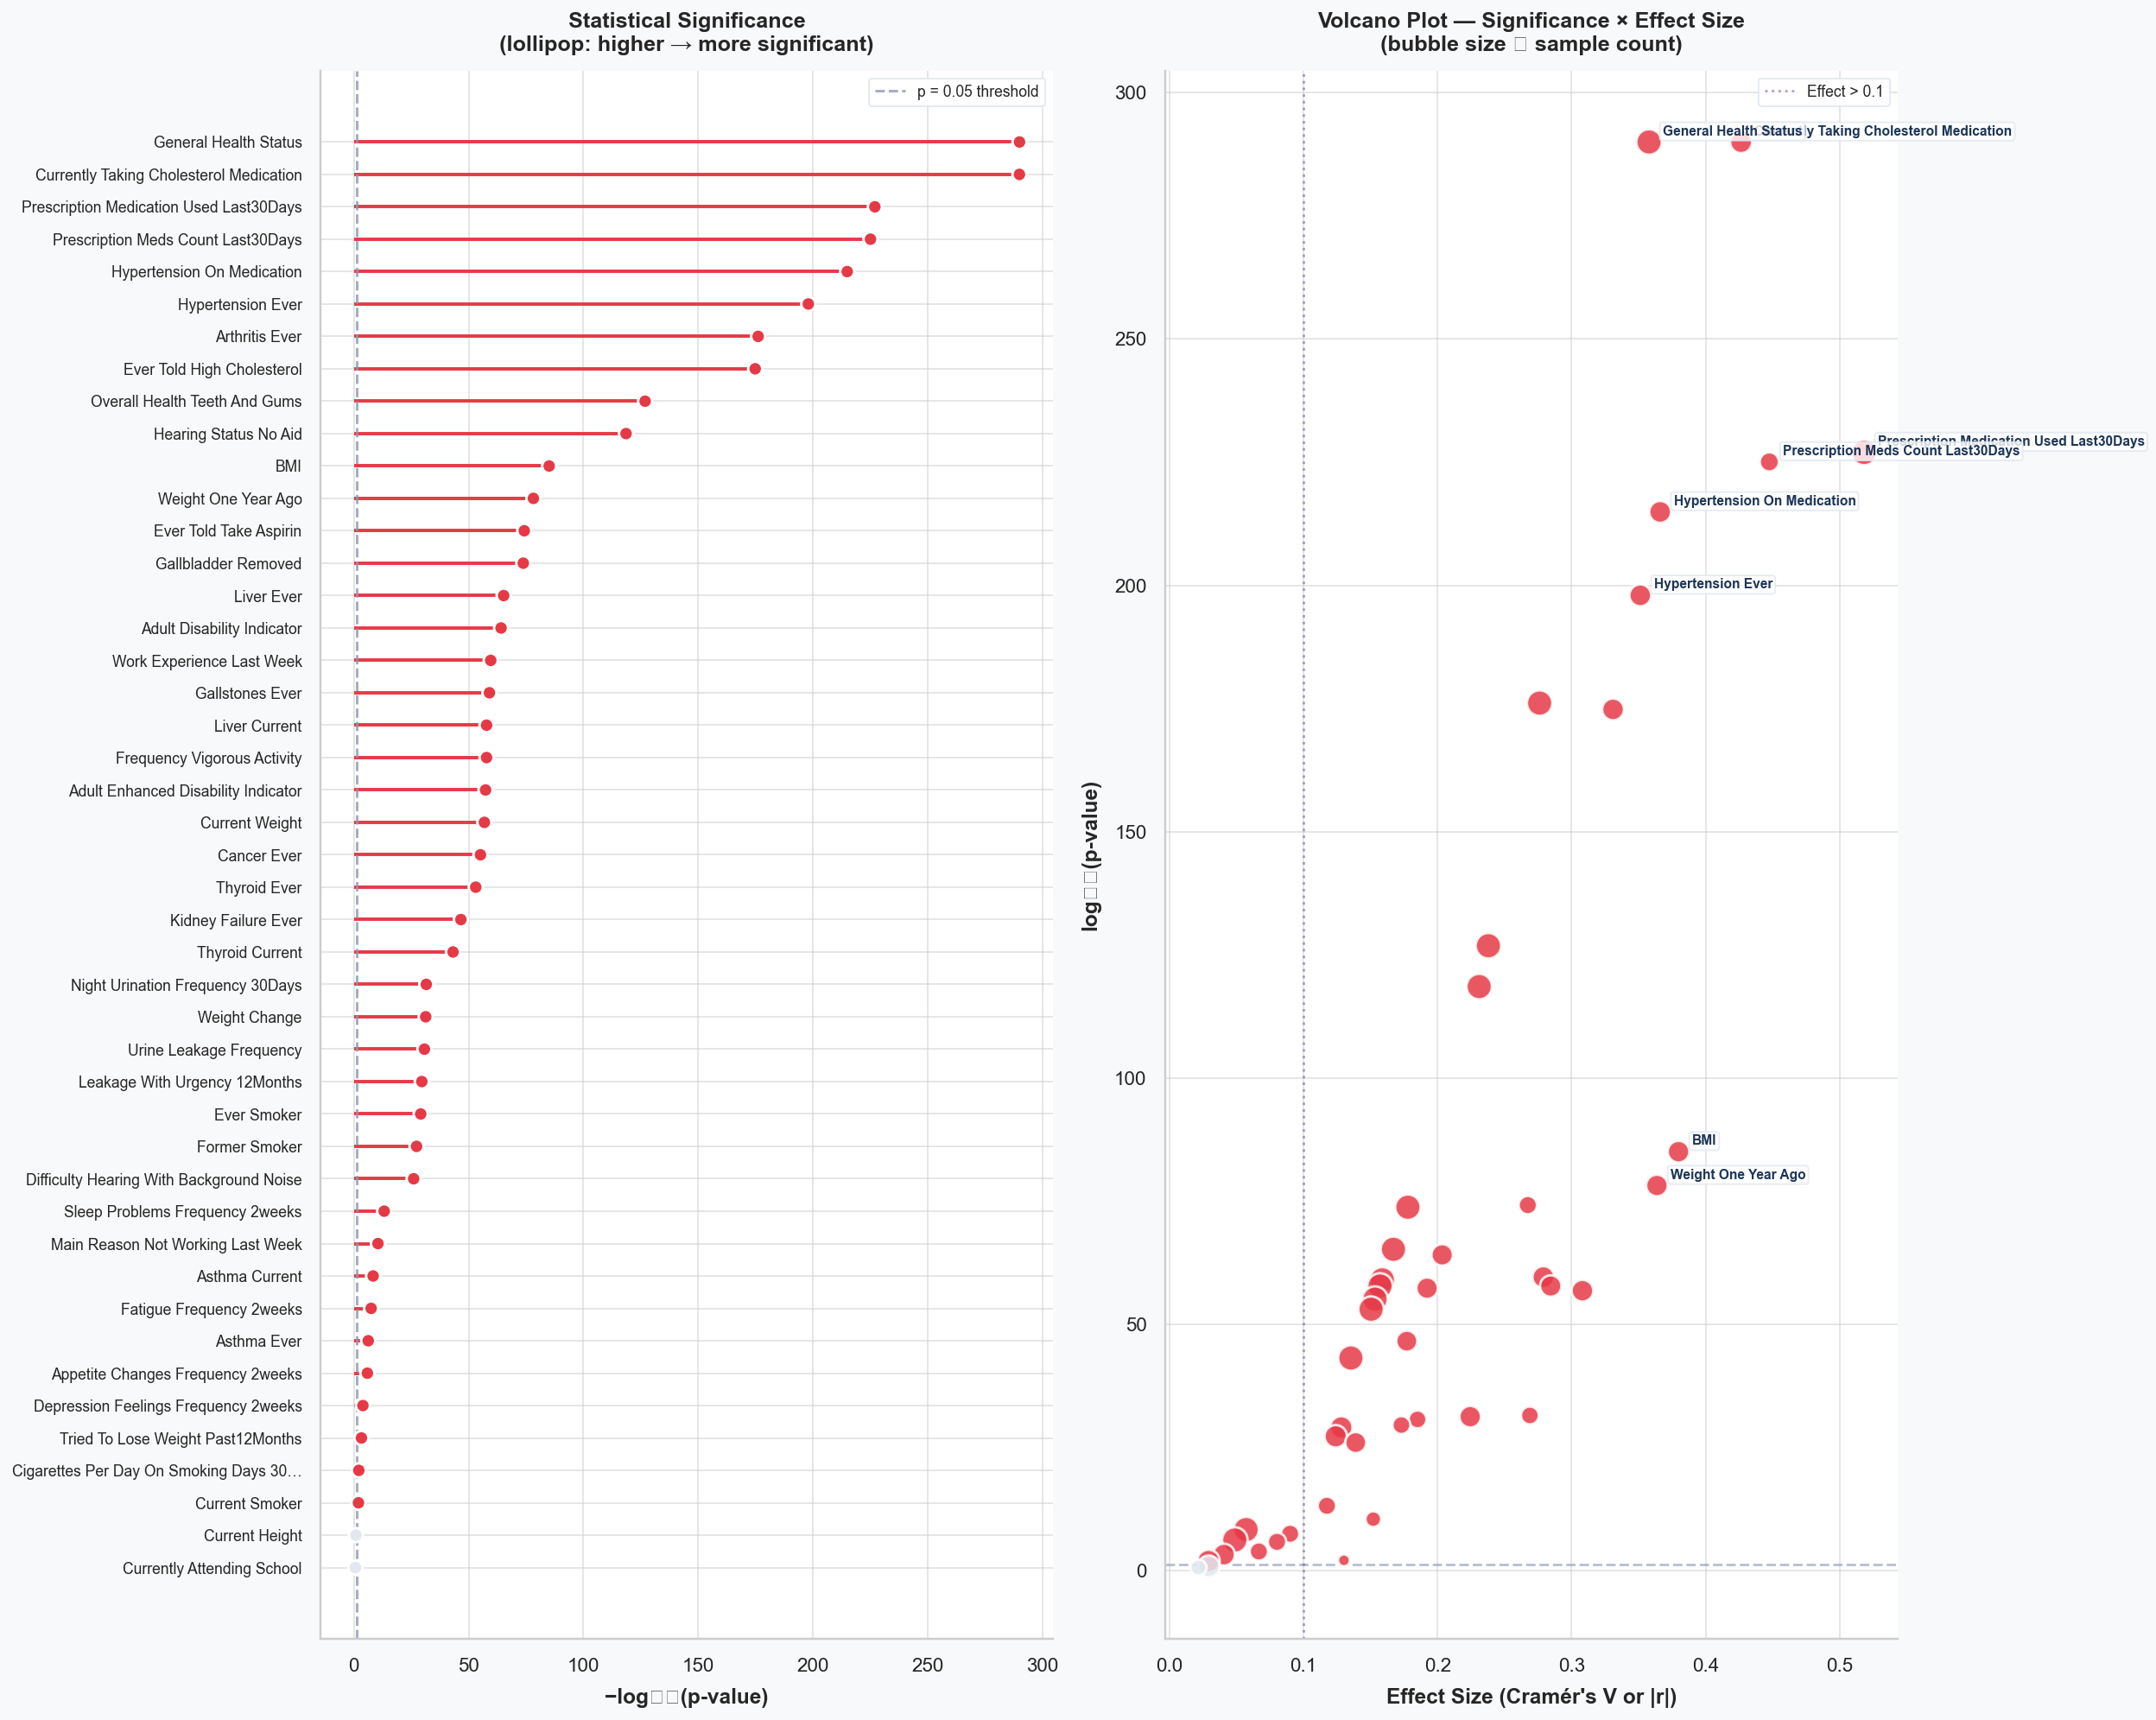


43 / 45 features are statistically significant (p < 0.05).


In [239]:
# ── Volcano-Style Plot: Effect Size vs Significance ──
fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(stat_df) * 0.32)))

# ── LEFT: -log10(p) horizontal lollipop ──
ax = axes[0]
stat_sorted = stat_df.sort_values('p-value', ascending=False)
neg_logp = -np.log10(stat_sorted['p-value'].clip(lower=1e-300))
sig_mask = stat_sorted['Significant (p<0.05)'].values

y_pos = np.arange(len(stat_sorted))
colors_sig = [COLORS['diab'] if s else COLORS['grid'] for s in sig_mask]

ax.hlines(y_pos, 0, neg_logp, color=colors_sig, linewidth=2, zorder=2)
ax.scatter(neg_logp, y_pos, s=70, color=colors_sig, edgecolors='white',
           linewidths=1.5, zorder=3)
ax.axvline(-np.log10(0.05), ls='--', color=COLORS['neutral'], alpha=0.8,
           label='p = 0.05 threshold')
ax.set_xlabel('−log₁₀(p-value)', fontweight='bold')
ax.set_yticks(y_pos)
ax.set_yticklabels([nice(f) for f in stat_sorted['Feature']], fontsize=9)
ax.set_title('Statistical Significance\n(lollipop: higher → more significant)', fontsize=13, pad=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── RIGHT: Volcano — Effect Size vs -log10(p) scatter ──
ax2 = axes[1]
neg_logp_all = -np.log10(stat_df['p-value'].clip(lower=1e-300))
sig_all = stat_df['Significant (p<0.05)'].values
eff_all = stat_df['Effect Size'].values

# Size by sample count
sizes = (stat_df['n'] / stat_df['n'].max()) * 200 + 30

scatter_colors = [COLORS['diab'] if s else COLORS['grid'] for s in sig_all]
ax2.scatter(eff_all, neg_logp_all, s=sizes, c=scatter_colors,
            edgecolors='white', linewidths=1.5, alpha=0.85, zorder=3)
ax2.axhline(-np.log10(0.05), ls='--', color=COLORS['neutral'], alpha=0.6)
ax2.axvline(0.1, ls=':', color=COLORS['accent'], alpha=0.5, label='Effect > 0.1')

# Label top features
top_feats = stat_df.nlargest(8, 'Effect Size')
for _, row in top_feats.iterrows():
    ax2.annotate(nice(row['Feature']),
                 xy=(row['Effect Size'], -np.log10(max(row['p-value'], 1e-300))),
                 xytext=(8, 4), textcoords='offset points',
                 fontsize=8, fontweight='bold', color=COLORS['dark'],
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=COLORS['grid'], alpha=0.8))

ax2.set_xlabel('Effect Size (Cramér\'s V or |r|)', fontweight='bold')
ax2.set_ylabel('log₁₀(p-value)', fontweight='bold')
ax2.set_title('Volcano Plot — Significance × Effect Size\n(bubble size ∝ sample count)', fontsize=13, pad=12)
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('Results/exploring/eda_stat_tests.png', bbox_inches='tight')
plt.show()

n_sig = stat_df['Significant (p<0.05)'].sum()
print(f'\n{n_sig} / {len(stat_df)} features are statistically significant (p < 0.05).')

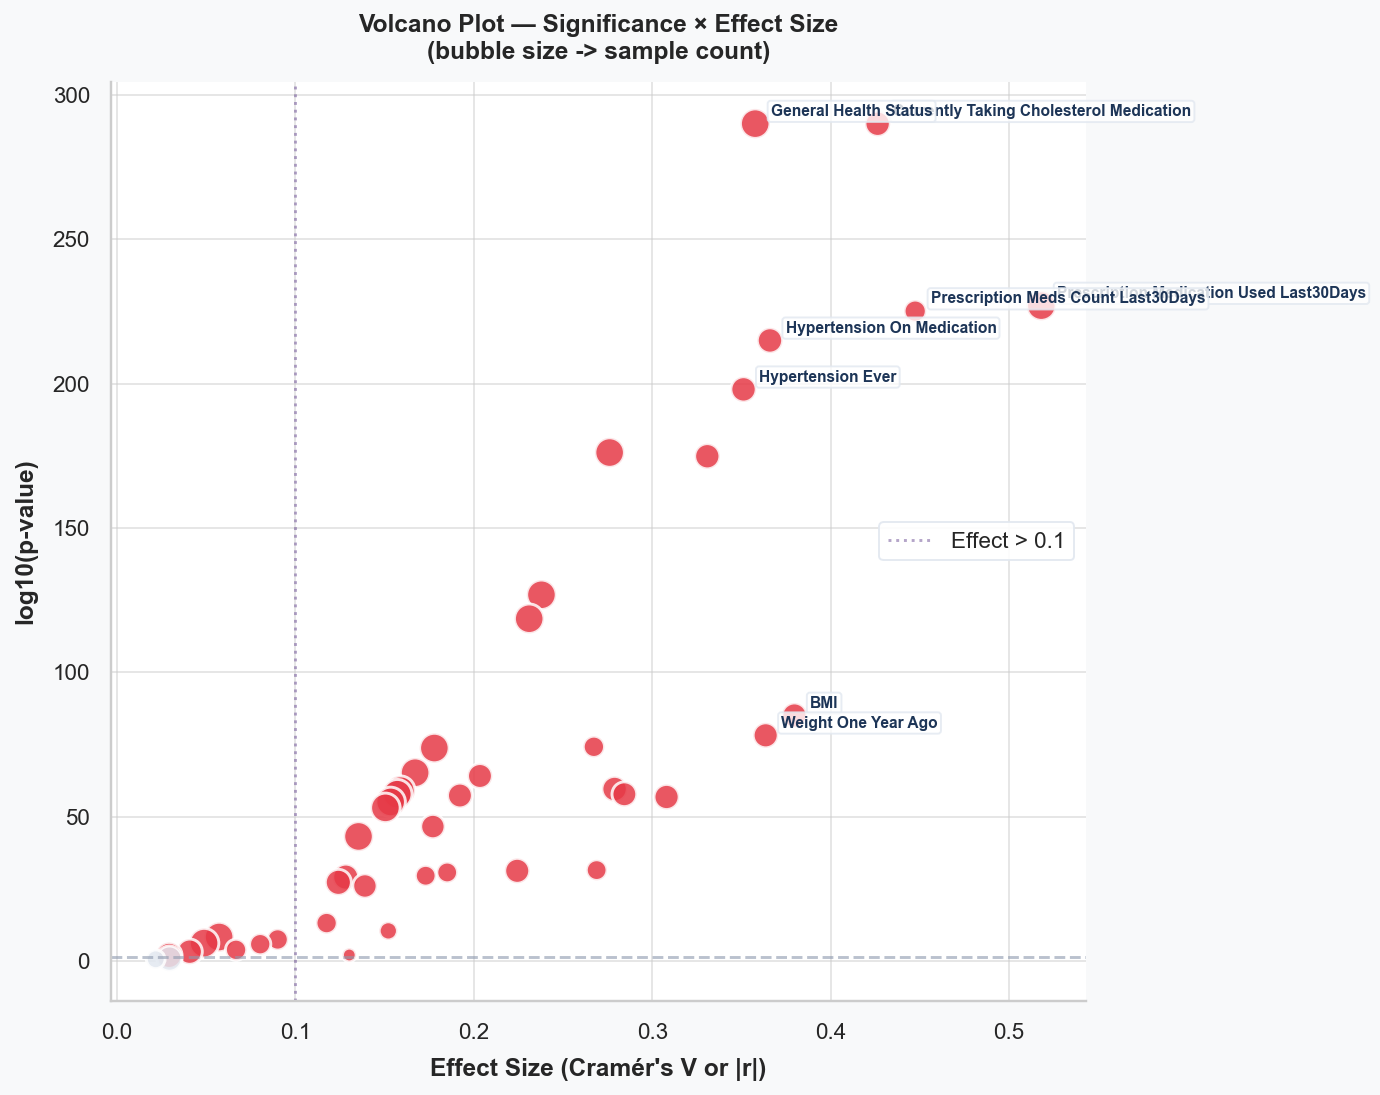


43 / 45 features are statistically significant (p < 0.05).


In [240]:
# ── Volcano Plot: Effect Size vs Significance ──
plt.figure(figsize=(10, 8))

neg_logp = -np.log10(stat_df['p-value'].clip(lower=1e-300))
sig = stat_df['Significant (p<0.05)'].values
eff = stat_df['Effect Size'].values

# Size by sample count
sizes = (stat_df['n'] / stat_df['n'].max()) * 200 + 30
colors = [COLORS['diab'] if s else COLORS['grid'] for s in sig]

plt.scatter(eff, neg_logp, s=sizes, c=colors,
            edgecolors='white', linewidths=1.5, alpha=0.85)

# Threshold lines
plt.axhline(-np.log10(0.05), ls='--', color=COLORS['neutral'], alpha=0.6)
plt.axvline(0.1, ls=':', color=COLORS['accent'], alpha=0.5, label='Effect > 0.1')

# Label top features
top_feats = stat_df.nlargest(8, 'Effect Size')
for _, row in top_feats.iterrows():
    plt.annotate(
        nice(row['Feature']),
        xy=(row['Effect Size'], -np.log10(max(row['p-value'], 1e-300))),
        xytext=(8, 4),
        textcoords='offset points',
        fontsize=8,
        fontweight='bold',
        color=COLORS['dark'],
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=COLORS['grid'], alpha=0.8)
    )

plt.xlabel("Effect Size (Cramér's V or |r|)", fontweight='bold')
plt.ylabel('log10(p-value)', fontweight='bold')
plt.title('Volcano Plot — Significance × Effect Size\n(bubble size -> sample count)', pad=12)
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('Results/exploring/eda_volcano.png', bbox_inches='tight')
plt.show()

n_sig = stat_df['Significant (p<0.05)'].sum()
print(f'\n{n_sig} / {len(stat_df)} features are statistically significant (p < 0.05).')


---
## 6. Mutual Information

Mutual Information captures *non-linear* dependencies between each feature and the target.  
This complements the linear correlation analysis above.

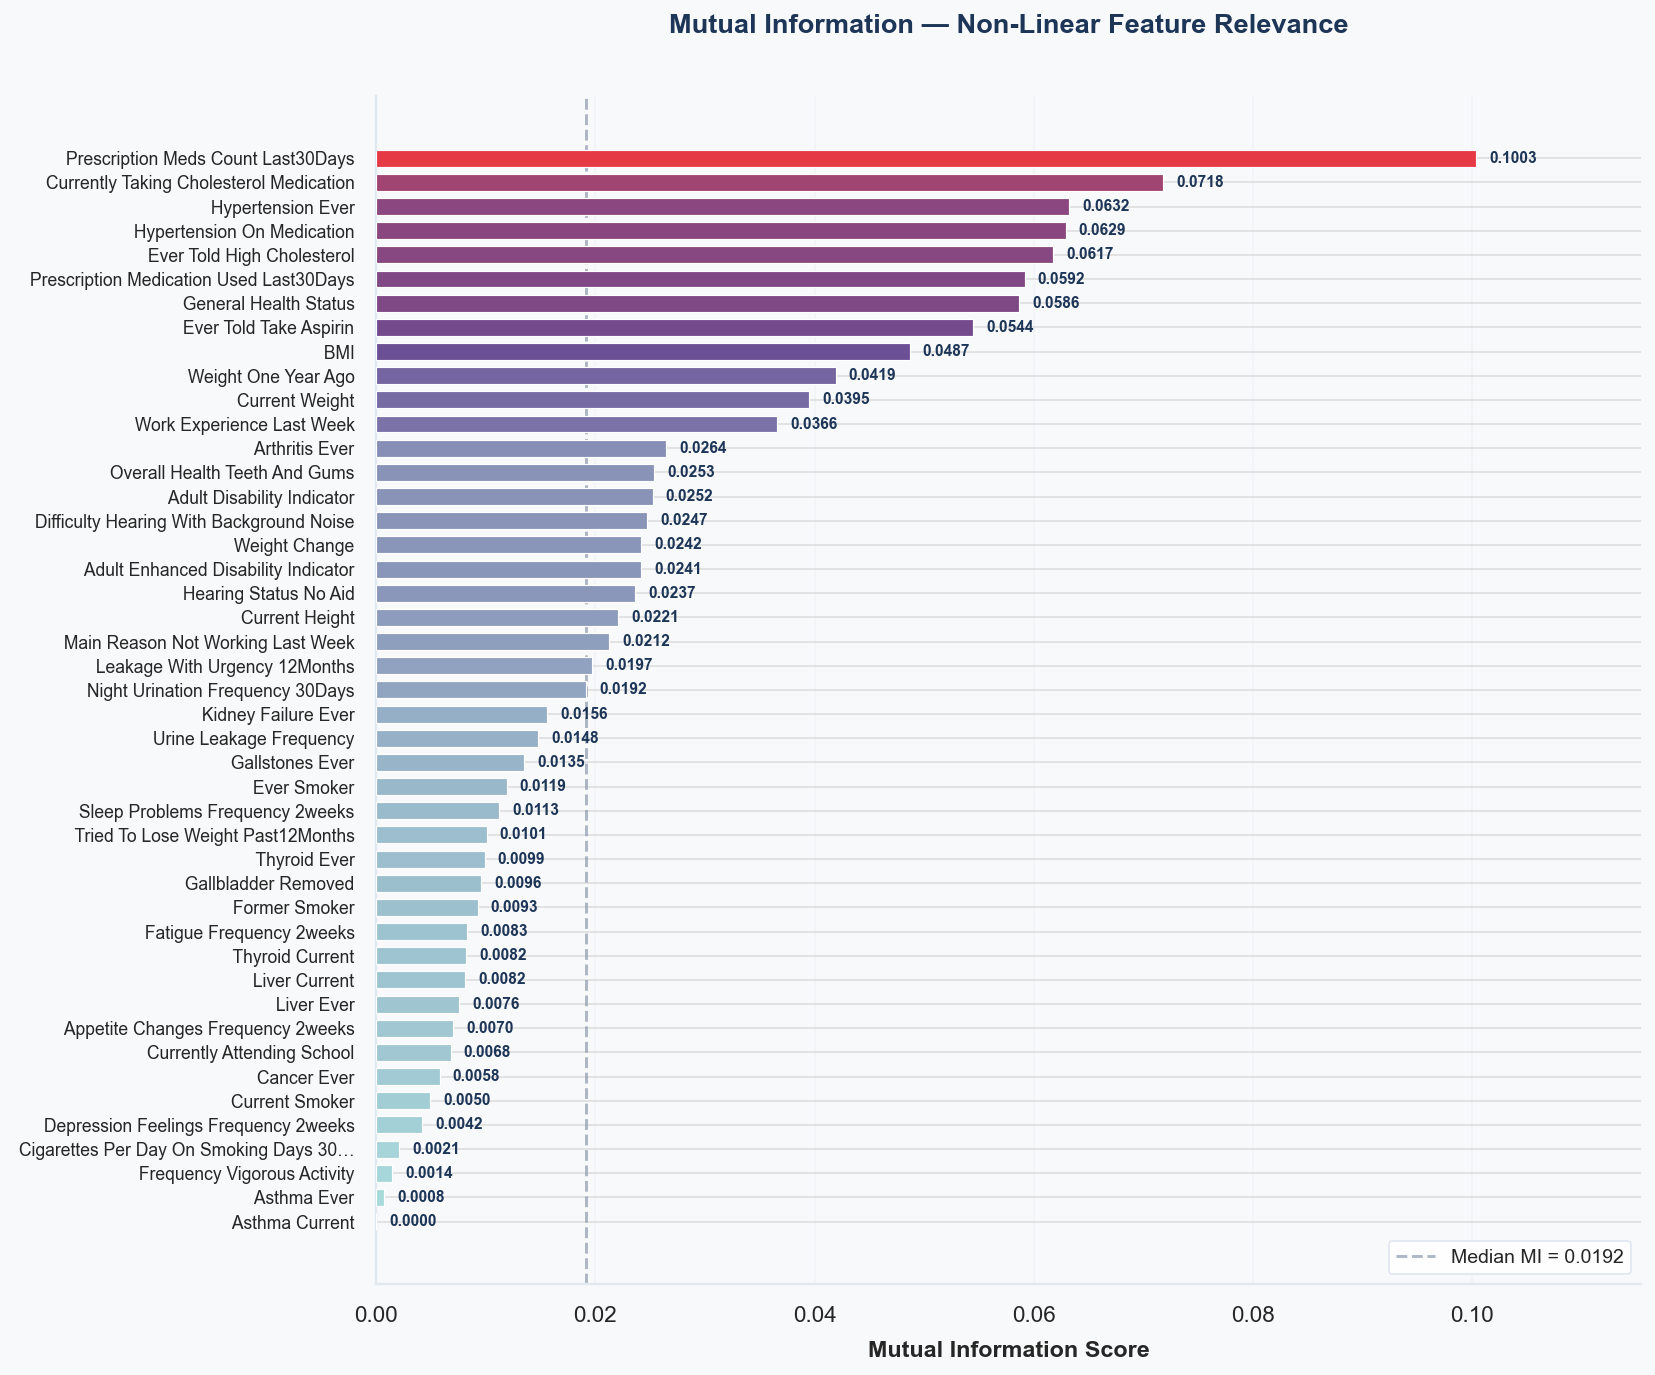


Top 10 features by Mutual Information:
                  Feature  MI_Score
                   RXQ050    0.1003
                  BPQ101D    0.0718
        Hypertension_Ever    0.0632
Hypertension_OnMedication    0.0629
                   BPQ080    0.0617
                   RXQ033    0.0592
                   HUQ010    0.0586
                   RXQ510    0.0544
                      BMI    0.0487
                   WHD050    0.0419


In [241]:
from sklearn.feature_selection import mutual_info_classif

# ── Mutual Information scores ──
X_mi = combined[feat_cols].copy()
y_mi = combined['diabetes_class'].copy()
valid = y_mi.notna()
X_mi, y_mi = X_mi[valid], y_mi[valid].astype(int)
X_mi = X_mi.fillna(X_mi.median())

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42, n_neighbors=5)
mi_df = pd.DataFrame({'Feature': feat_cols, 'MI_Score': mi_scores}).sort_values('MI_Score', ascending=False)

# ── Aesthetic Horizontal Bar Plot — Mutual Information ──
mi_sorted = mi_df.sort_values('MI_Score', ascending=True)
n_feat = len(mi_sorted)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['bg'])

y_pos = np.arange(n_feat)

# Gradient colour per bar
cmap_mi = LinearSegmentedColormap.from_list('mi', [COLORS['light'], COLORS['accent'], COLORS['diab']])
norm_mi = plt.Normalize(mi_sorted['MI_Score'].min(), mi_sorted['MI_Score'].max())
bar_colors = [cmap_mi(norm_mi(v)) for v in mi_sorted['MI_Score']]

bars = ax.barh(y_pos, mi_sorted['MI_Score'], height=0.7, color=bar_colors,
               edgecolor='white', linewidth=0.6, zorder=3)

# Value labels at bar tips
for bar, val in zip(bars, mi_sorted['MI_Score']):
    ax.text(bar.get_width() + mi_sorted['MI_Score'].max() * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left',
            fontsize=8, color=COLORS['dark'], fontweight='bold')

# Median reference line
median_mi = mi_df['MI_Score'].median()
ax.axvline(median_mi, ls='--', lw=1.5, color=COLORS['neutral'], alpha=0.7,
           label=f'Median MI = {median_mi:.4f}', zorder=2)

# Y-tick labels with ✓/✗ markers
feat_labels = []
for f in mi_sorted['Feature']:
    # marker = '' if f in FINAL_FEATURES else '✗'
    feat_labels.append(f' {nice(f)}')

ax.set_yticks(y_pos)
ax.set_yticklabels(feat_labels, fontsize=9)
ax.set_xlabel('Mutual Information Score', fontweight='bold', fontsize=12)
ax.set_title('Mutual Information — Non-Linear Feature Relevance\n',
             fontsize=14, fontweight='bold', color=COLORS['dark'], pad=18)
ax.legend(fontsize=10, loc='lower right',
          frameon=True, facecolor='white', edgecolor=COLORS['grid'])
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_color(COLORS['grid'])
ax.spines['bottom'].set_color(COLORS['grid'])
ax.grid(axis='x', alpha=0.25, color=COLORS['grid'], zorder=0)
ax.set_xlim(0, mi_sorted['MI_Score'].max() * 1.15)

plt.tight_layout()
plt.savefig('Results/exploring/eda_mutual_info.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nTop 10 features by Mutual Information:')
print(mi_df.head(10).to_string(index=False))